## Z-score each residual across classes + cluster both axes

Same selectivity measure as the genus block below, but with the class as the
grouping unit. Each residual is standardized across classes, so entry `(c, j)`
reads as: how unusual is residual `j`'s share of the residual budget for class
`c`, relative to what residual `j` normally takes across all classes.

Caveat: a class has far fewer test samples than a genus (~30 for CUB), so
`mean_per_sample_share` is a noisier estimate here and |z| is correspondingly
inflated. Read the top pairs together with `num_samples`.

In [ ]:
# ============================================================
# Class x residual selectivity matrix
# ============================================================

import numpy as np
import pandas as pd


# ------------------------------------------------------------
# 1. Create class x residual matrix
# ------------------------------------------------------------

# Classes with no test samples were kept as NaN placeholder rows
# in all_residuals_per_class_df, so drop them before pivoting.
class_df_for_pivot = (
    all_residuals_per_class_df
    .dropna(subset=["residual_idx"])
)

class_df_for_pivot = class_df_for_pivot[
    class_df_for_pivot["num_samples"] > 0
]

class_residual_share = (
    class_df_for_pivot
    .pivot(
        index="class_idx",
        columns="residual_idx",
        values="mean_per_sample_share",
    )
)

# Readable row labels for the plots below.
class_idx_to_name = (
    class_df_for_pivot
    .drop_duplicates("class_idx")
    .set_index("class_idx")["class_name"]
    .to_dict()
)

class_labels = [
    f"{int(class_idx):03d} {class_idx_to_name[class_idx]}"
    for class_idx in class_residual_share.index
]

print(
    "Class x residual matrix:",
    class_residual_share.shape,
)

print(
    "Classes dropped (no test samples):",
    all_residuals_per_class_df["class_idx"].nunique()
    - class_residual_share.shape[0],
)


# ------------------------------------------------------------
# 2. Z-score EACH residual across classes
# ------------------------------------------------------------

# axis=0 reduces over classes, so the mean and std are taken
# per residual. Entry (c, j) then measures how far residual j's
# share for class c sits from residual j's own average share.

class_share_std = class_residual_share.std(axis=0, ddof=0)

degenerate_residuals = (
    class_share_std.index[class_share_std == 0]
    .astype(int)
    .tolist()
)

if degenerate_residuals:
    print(
        "Residuals with zero variance across classes "
        "(z set to 0):",
        degenerate_residuals,
    )

class_residual_z = (
    (
        class_residual_share
        - class_residual_share.mean(axis=0)
    )
    / class_share_std.replace(0.0, np.nan)
).fillna(0.0)


display(class_residual_z.head(10))


Class x residual matrix: (200, 50)
Classes dropped (no test samples): 0


residual_idx,0,1,2,3,4,5,6,7,8,9,...,40,41,42,43,44,45,46,47,48,49
class_idx,,,,,,,,,,,,,,,,,,,,,
0,-1.682481,0.984547,-1.361673,0.147811,-0.288541,-0.498723,0.228559,1.648498,2.346451,-0.251272,...,0.853613,-0.613139,-0.585449,0.123578,2.751392,-1.403922,1.844362,-0.349485,1.930766,-0.609537
1,-1.500886,0.018808,-1.072987,-0.284572,-0.080491,-0.784454,0.226066,0.807333,0.628285,0.142474,...,-1.132293,0.723670,1.023941,0.303682,0.777942,-0.764262,0.391766,-0.073090,0.493995,-0.280915
2,-0.166794,0.740164,-0.730754,0.058716,-0.502411,-0.932661,-0.296131,-0.123477,2.223956,-0.533481,...,0.401939,0.839841,-0.524405,-0.148802,2.565847,-1.051157,2.228047,-0.456436,2.826731,0.973430
3,1.264095,0.731881,0.186469,-0.469943,-0.096620,-1.005982,-1.366395,0.015318,0.028710,-1.372019,...,0.316942,-0.337899,0.019010,-0.234597,-0.168824,1.629240,0.150468,0.538314,0.789538,0.192997
4,-0.074591,0.930692,0.112004,1.278987,-0.261141,-1.192202,2.815351,-0.111221,1.319196,-0.290345,...,1.108143,-0.782675,1.167466,1.434313,0.057350,-0.653577,0.042542,-0.568996,1.831463,1.030193
5,-1.056370,2.461664,-0.776947,0.826966,-0.613189,-1.325490,1.787512,-0.634990,0.730163,-1.304907,...,0.479257,-1.450715,1.298447,-0.468047,2.355349,-0.815591,2.092477,-0.275985,1.828186,1.003639
6,-1.803928,-1.311790,0.057251,2.099891,-0.085364,0.968923,1.733310,1.191692,1.580480,-1.301742,...,0.028109,-0.069823,0.143980,1.678590,2.583074,-0.548450,-0.643907,-0.640371,0.662117,1.028357
7,-0.859931,1.361137,-1.043292,0.661274,-0.737295,-0.909650,1.492870,0.104912,1.502984,-1.348601,...,-0.523520,-0.601965,0.241714,1.057008,0.912613,-1.036776,1.775157,0.372936,-0.056037,1.244653
8,0.893608,1.788467,-0.415642,-0.632171,-0.679252,-0.495808,-0.288219,0.433237,0.825392,-0.606109,...,-0.144100,-0.877729,-0.011595,1.515255,-0.785238,0.449899,-0.266112,1.324168,0.936691,1.833423


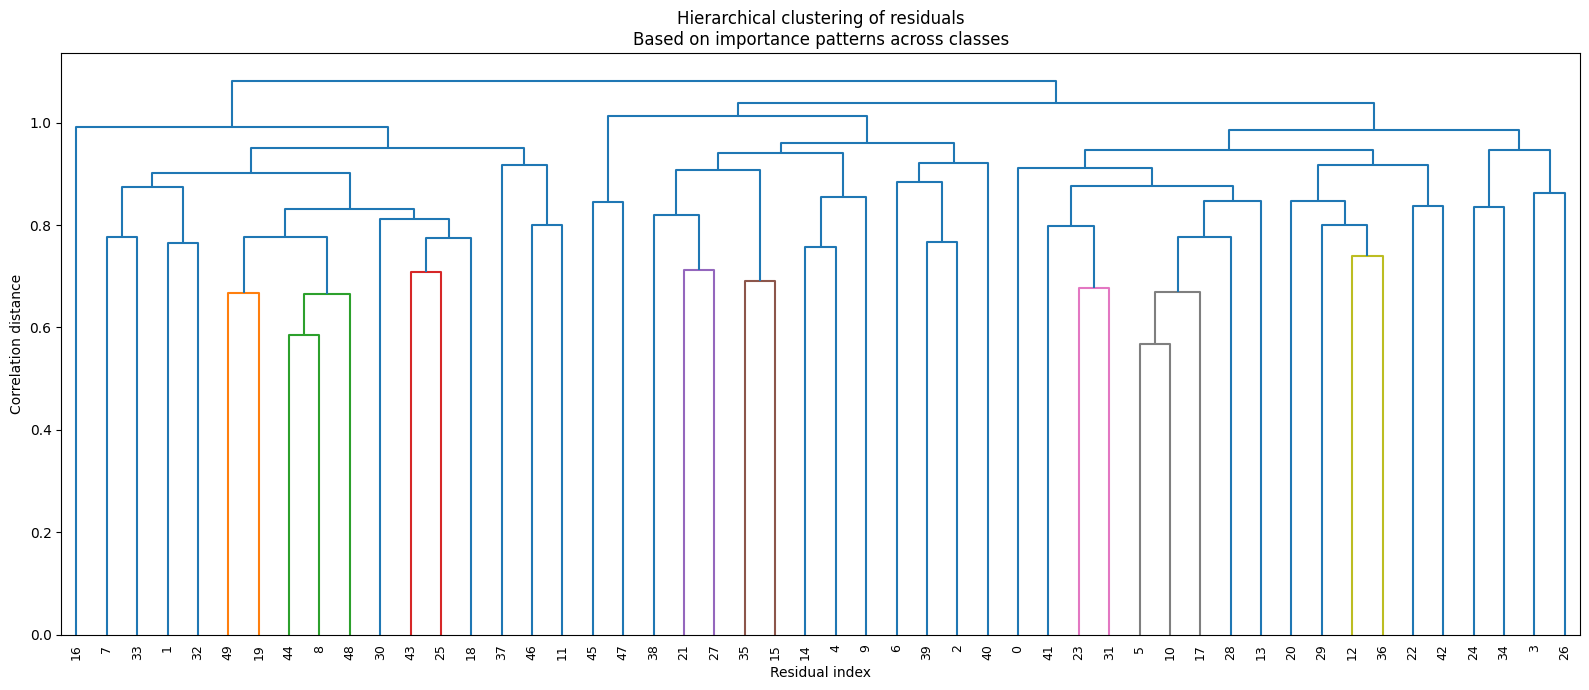

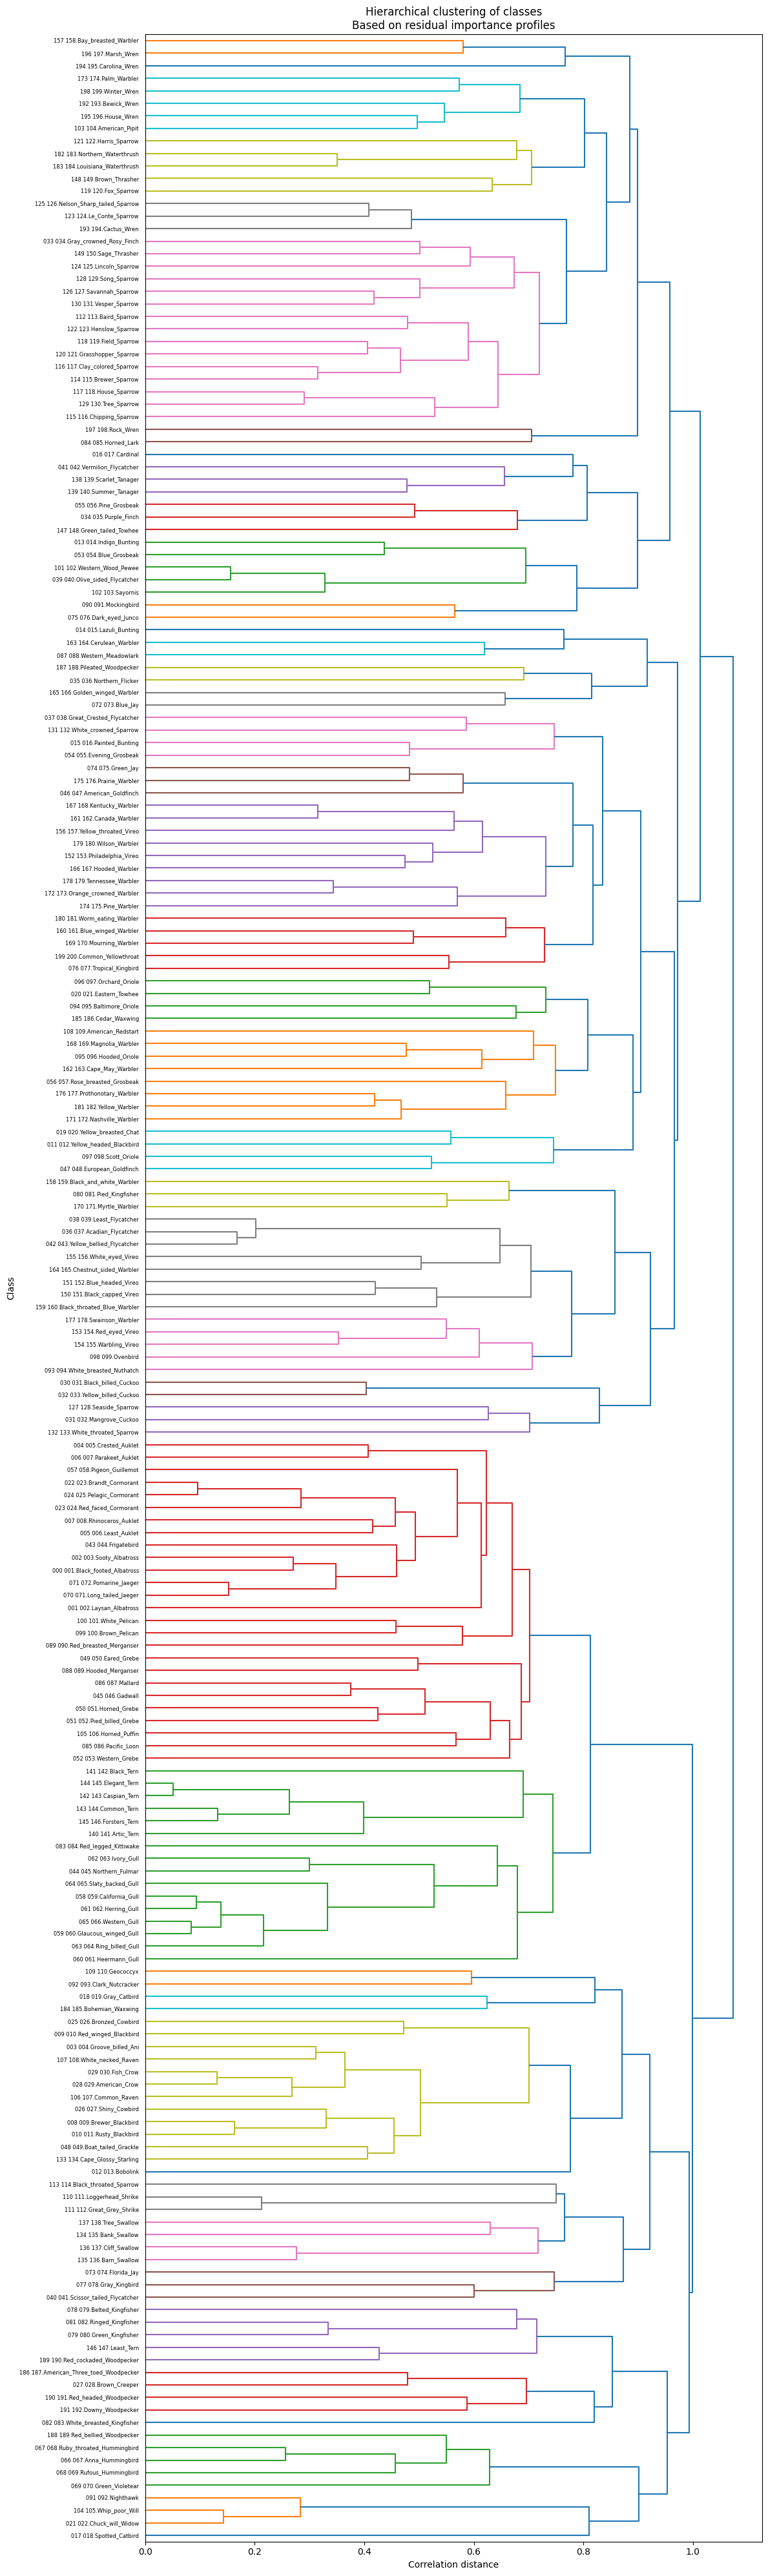

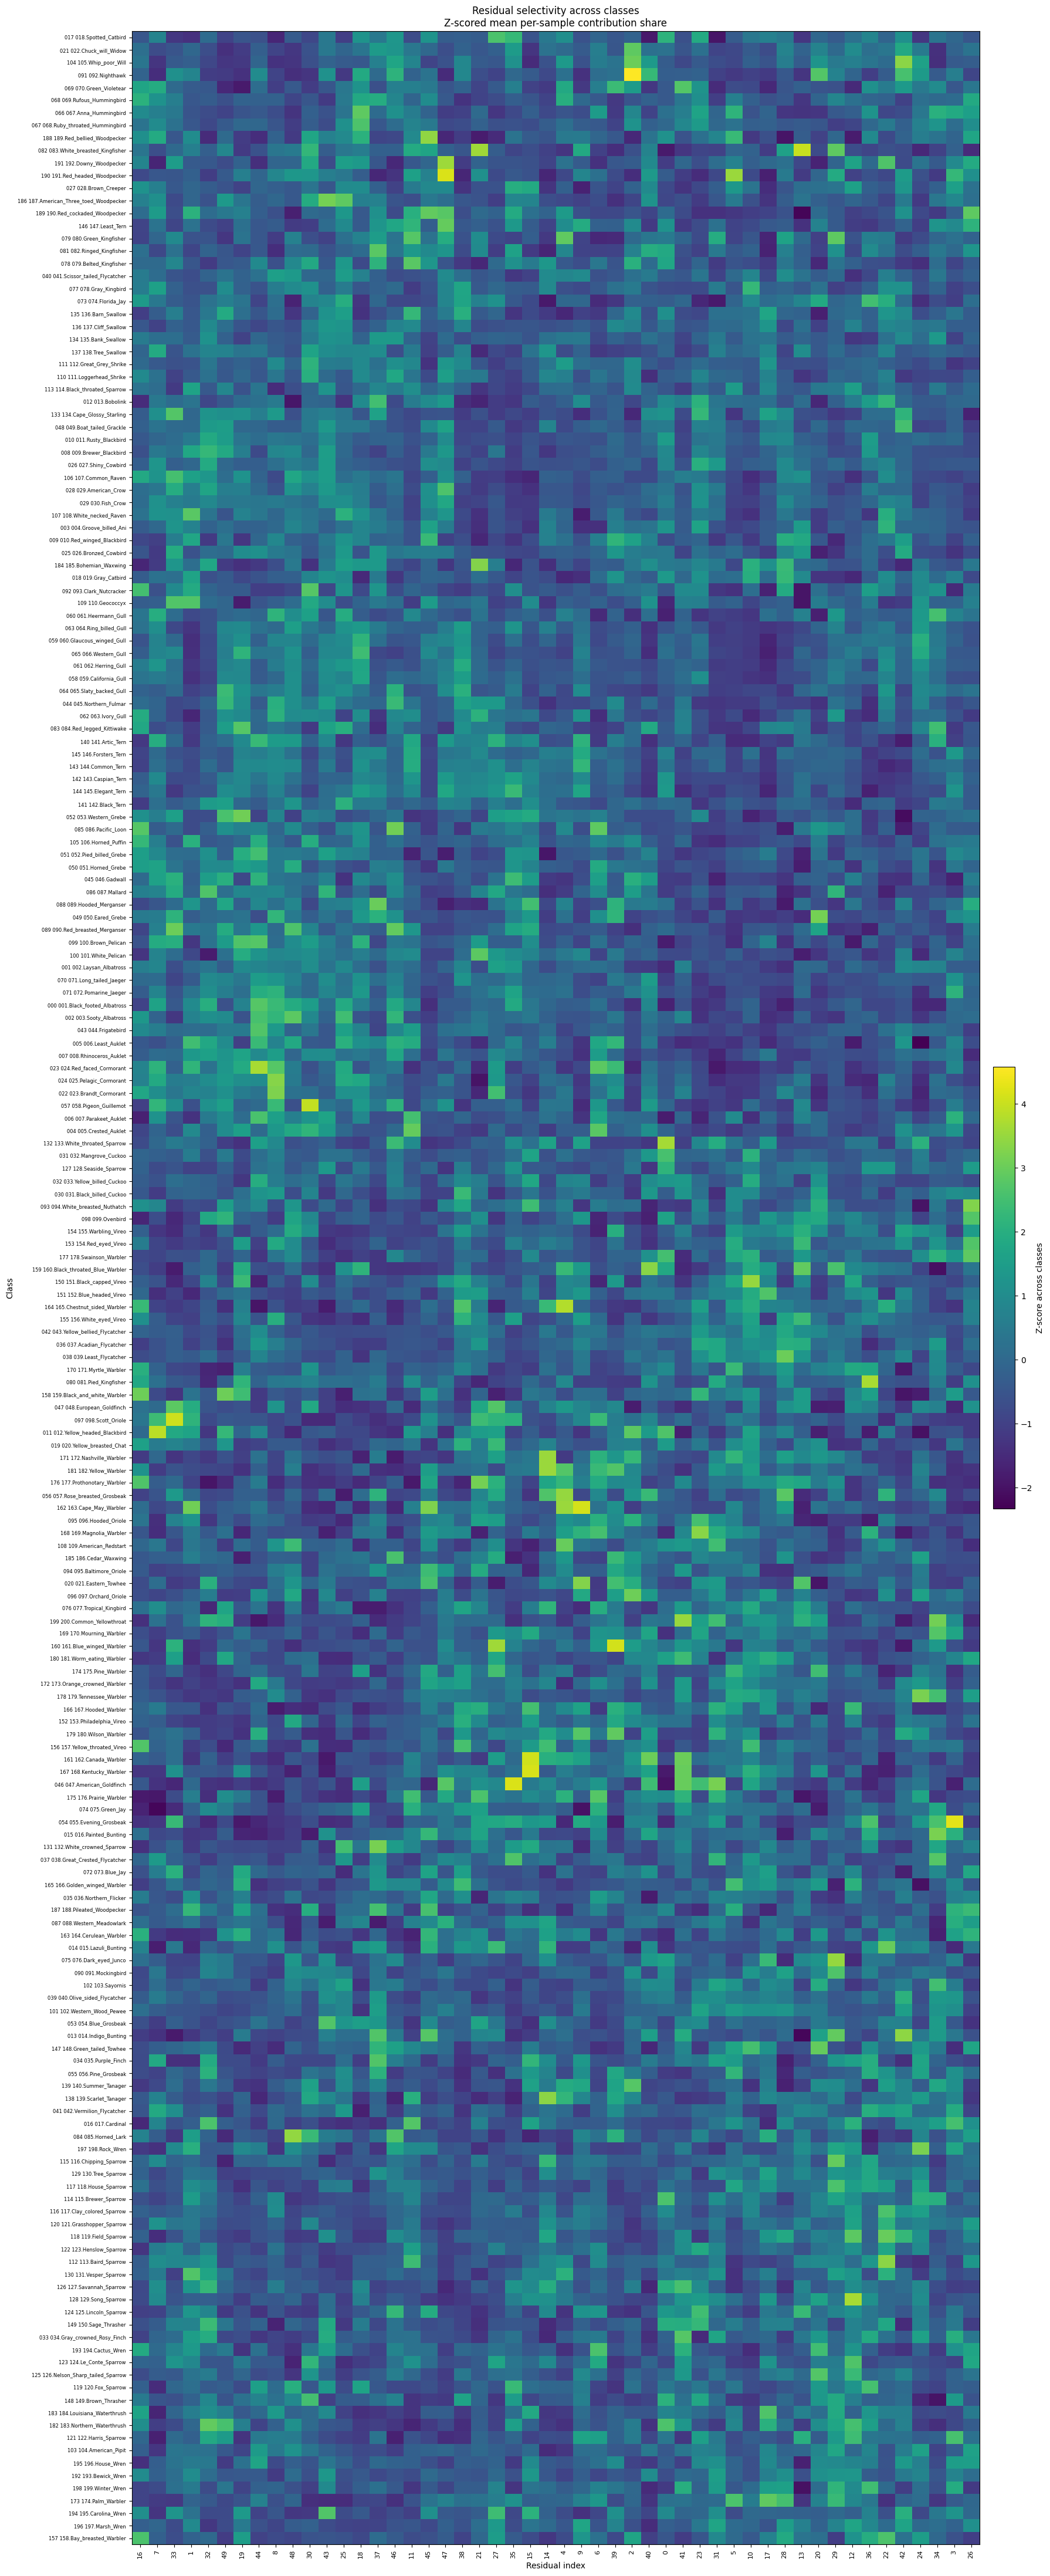

In [ ]:
# ============================================================
# Separate plots:
#   1. Residual dendrogram
#   2. Class dendrogram
#   3. Clustered class x residual heatmap
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.cluster.hierarchy import linkage, dendrogram, leaves_list
from scipy.spatial.distance import pdist


# ------------------------------------------------------------
# 1. Drop constant rows/columns
# ------------------------------------------------------------

# Correlation distance is undefined for a constant profile, so
# remove those before clustering rather than propagating NaNs.

row_variance = class_residual_z.var(axis=1, ddof=0)
col_variance = class_residual_z.var(axis=0, ddof=0)

z_for_clustering = class_residual_z.loc[
    row_variance > 0,
    col_variance > 0,
]

if z_for_clustering.shape != class_residual_z.shape:
    print(
        "Dropped constant profiles before clustering:",
        class_residual_z.shape,
        "->",
        z_for_clustering.shape,
    )

cluster_class_labels = [
    f"{int(class_idx):03d} {class_idx_to_name[class_idx]}"
    for class_idx in z_for_clustering.index
]


# ------------------------------------------------------------
# 2. Calculate correlation distances
# ------------------------------------------------------------

# Classes:
# Compare residual-importance patterns between classes
class_distance = pdist(
    z_for_clustering.values,
    metric="correlation",
)

# Residuals:
# Compare class-selectivity patterns between residuals
residual_distance_classes = pdist(
    z_for_clustering.values.T,
    metric="correlation",
)


# ------------------------------------------------------------
# 3. Hierarchical clustering
# ------------------------------------------------------------

class_linkage = linkage(
    class_distance,
    method="average",
    optimal_ordering=True,
)

residual_linkage_classes = linkage(
    residual_distance_classes,
    method="average",
    optimal_ordering=True,
)


# ------------------------------------------------------------
# 4. Get clustered ordering
# ------------------------------------------------------------

class_order = leaves_list(class_linkage)
residual_order_classes = leaves_list(residual_linkage_classes)

clustered_class_z = z_for_clustering.iloc[
    class_order,
    residual_order_classes,
]


# ============================================================
# PLOT 1: Residual clustering
# ============================================================

plt.figure(figsize=(16, 7))

dendrogram(
    residual_linkage_classes,
    labels=z_for_clustering.columns.astype(int).astype(str),
    leaf_rotation=90,
    leaf_font_size=9,
)

plt.title(
    "Hierarchical clustering of residuals\n"
    "Based on importance patterns across classes"
)

plt.xlabel("Residual index")
plt.ylabel("Correlation distance")

plt.tight_layout()
plt.show()


# ============================================================
# PLOT 2: Class clustering
# ============================================================

plt.figure(figsize=(12, 40))

dendrogram(
    class_linkage,
    labels=cluster_class_labels,
    orientation="right",
    leaf_font_size=6,
)

plt.title(
    "Hierarchical clustering of classes\n"
    "Based on residual importance profiles"
)

plt.xlabel("Correlation distance")
plt.ylabel("Class")

plt.tight_layout()
plt.show()


# ============================================================
# PLOT 3: Clustered heatmap
# ============================================================

fig, ax = plt.subplots(
    figsize=(18, 44)
)

im = ax.imshow(
    clustered_class_z.values,
    aspect="auto",
    interpolation="nearest",
)

# Residual labels
ax.set_xticks(
    np.arange(clustered_class_z.shape[1])
)

ax.set_xticklabels(
    clustered_class_z.columns.astype(int),
    rotation=90,
    fontsize=8,
)

# Class labels
ax.set_yticks(
    np.arange(clustered_class_z.shape[0])
)

ax.set_yticklabels(
    [
        f"{int(class_idx):03d} {class_idx_to_name[class_idx]}"
        for class_idx in clustered_class_z.index
    ],
    fontsize=6,
)

ax.set_xlabel("Residual index")
ax.set_ylabel("Class")

ax.set_title(
    "Residual selectivity across classes\n"
    "Z-scored mean per-sample contribution share"
)

cbar = fig.colorbar(
    im,
    ax=ax,
    fraction=0.025,
    pad=0.015,
)

cbar.set_label(
    "Z-score across classes"
)

plt.tight_layout()
plt.show()


In [ ]:
# ============================================================
# Rank all class x residual pairs by selectivity
# ============================================================

# class_residual_z:
# rows    = class indices
# columns = residual indices
# values  = z-scored mean per-sample contribution share


# ------------------------------------------------------------
# 1. Convert matrix into long-form dataframe
# ------------------------------------------------------------

ranked_class_pairs = (
    class_residual_z
    .stack()
    .reset_index()
)

ranked_class_pairs.columns = [
    "class_idx",
    "residual_idx",
    "z_score",
]


# ------------------------------------------------------------
# 2. Add original contribution share and class context
# ------------------------------------------------------------

class_share_long = (
    class_residual_share
    .stack()
    .reset_index()
)

class_share_long.columns = [
    "class_idx",
    "residual_idx",
    "mean_per_sample_share",
]

ranked_class_pairs = ranked_class_pairs.merge(
    class_share_long,
    on=["class_idx", "residual_idx"],
    how="left",
)

ranked_class_pairs["class_name"] = (
    ranked_class_pairs["class_idx"].map(class_idx_to_name)
)

# num_samples matters here: a class has ~30 test images, so a
# large z can come from a noisy share estimate.
ranked_class_pairs = ranked_class_pairs.merge(
    class_df_for_pivot[
        [
            "class_idx",
            "residual_idx",
            "num_samples",
            "residual_position",
            "median_rank",
        ]
    ],
    on=["class_idx", "residual_idx"],
    how="left",
)


# ------------------------------------------------------------
# 3. Rank pairs
# ------------------------------------------------------------
# Highest z-score =
# residual is unusually important for this class

ranked_class_pairs = (
    ranked_class_pairs
    .sort_values(
        "z_score",
        ascending=False,
    )
    .reset_index(drop=True)
)

ranked_class_pairs["pair_rank"] = (
    np.arange(1, len(ranked_class_pairs) + 1)
)

ranked_class_pairs = ranked_class_pairs[
    [
        "pair_rank",
        "class_idx",
        "class_name",
        "residual_idx",
        "z_score",
        "mean_per_sample_share",
        "residual_position",
        "median_rank",
        "num_samples",
    ]
]


# ------------------------------------------------------------
# 4. Show strongest class-residual associations
# ------------------------------------------------------------

print(
    ranked_class_pairs.head(50).to_string(index=False)
)

ranked_class_pairs.to_csv(
    "delete_afterwards/ranked_class_residual_pairs_z_scores.csv",
    index=False,
)


 pair_rank  class_idx                         class_name  residual_idx  z_score  mean_per_sample_share  residual_position  median_rank  num_samples
         1         91                      092.Nighthawk             2 4.575294               0.065626                  1          2.0           30
         2         54               055.Evening_Grosbeak             3 4.281819               0.056458                  1          1.0           30
         3        190          191.Red_headed_Woodpecker            47 4.192680               0.053954                  4          1.0           30
         4         46             047.American_Goldfinch            35 4.191846               0.064120                  1          1.0           30
         5        167               168.Kentucky_Warbler            15 4.164194               0.061035                  1          1.0           29
         6        162               163.Cape_May_Warbler             9 4.138206               0.059544          

In [ ]:
# ============================================================
# Class - residual pairs with z-score over 2
# ============================================================

strong_residuals_per_class = (
    ranked_class_pairs[
        ranked_class_pairs["z_score"] >= 2
    ]
    .sort_values(
        ["class_idx", "z_score"],
        ascending=[True, False],
    )
    .reset_index(drop=True)
)

print(
    "Strong pairs:",
    len(strong_residuals_per_class),
    "of",
    len(ranked_class_pairs),
)

display(strong_residuals_per_class.head(20))


# For each residual find the number of classes with z_score >= 2
residual_class_counts = (
    strong_residuals_per_class
    .groupby("residual_idx")
    .size()
    .sort_values(ascending=False)
)

display(residual_class_counts.head(50))

residual_class_counts.to_csv(
    "delete_afterwards/residual_class_counts_z_score_ge_2.csv",
    header=["num_classes_z_ge_2"],
)


# Top residuals for each class
top_residuals_per_class = (
    ranked_class_pairs
    .sort_values(
        ["class_idx", "z_score"],
        ascending=[True, False],
    )
    .groupby("class_idx")
    .head(10)
    .reset_index(drop=True)
)

display(top_residuals_per_class.head(30))

top_residuals_per_class.to_csv(
    "delete_afterwards/top_residuals_per_class_z_scores.csv",
    index=False,
)


Strong pairs: 449 of 10000


,pair_rank,class_idx,class_name,residual_idx,z_score,mean_per_sample_share,residual_position,median_rank,num_samples
0,106,0,001.Black_footed_Albatross,44,2.751392,0.040635,8,4.0,30
1,252,0,001.Black_footed_Albatross,8,2.346451,0.041466,1,5.0,30
2,437,0,001.Black_footed_Albatross,32,2.010586,0.039416,4,5.0,30
3,94,2,003.Sooty_Albatross,48,2.826731,0.040140,3,8.0,28
4,173,2,003.Sooty_Albatross,44,2.565847,0.039136,5,6.0,28
5,207,2,003.Sooty_Albatross,25,2.466922,0.044683,1,4.0,28
6,296,2,003.Sooty_Albatross,46,2.228047,0.040909,4,3.0,28
7,298,2,003.Sooty_Albatross,8,2.223956,0.040338,2,5.0,28
8,331,3,004.Groove_billed_Ani,22,2.152059,0.039692,2,9.0,30
9,71,4,005.Crested_Auklet,11,2.940583,0.048422,3,2.0,14


residual_idx
34    13
39    13
22    12
4     12
33    12
46    12
37    12
11    12
0     11
27    11
29    11
16    11
1     11
44    11
45    11
8     11
6     11
14    10
10    10
5     10
32    10
3     10
2     10
41    10
38     9
30     9
49     9
23     9
12     9
13     9
19     9
26     8
42     8
18     7
47     7
15     7
17     7
35     7
20     7
21     7
31     7
36     6
28     6
9      6
25     6
40     5
24     5
48     5
43     4
7      4
dtype: int64

,pair_rank,class_idx,class_name,residual_idx,z_score,mean_per_sample_share,residual_position,median_rank,num_samples
0,106,0,001.Black_footed_Albatross,44,2.751392,0.040635,8,4.0,30
1,252,0,001.Black_footed_Albatross,8,2.346451,0.041466,1,5.0,30
2,437,0,001.Black_footed_Albatross,32,2.010586,0.039416,4,5.0,30
3,500,0,001.Black_footed_Albatross,48,1.930766,0.033041,7,9.0,30
4,549,0,001.Black_footed_Albatross,25,1.883205,0.038975,3,6.0,30
5,575,0,001.Black_footed_Albatross,35,1.853405,0.039730,5,4.0,30
6,585,0,001.Black_footed_Albatross,46,1.844362,0.037342,6,8.0,30
7,753,0,001.Black_footed_Albatross,7,1.648498,0.034759,9,7.0,30
8,901,0,001.Black_footed_Albatross,30,1.498882,0.036132,2,8.0,30
9,1626,0,001.Black_footed_Albatross,1,0.984547,0.030553,10,9.0,30


## -----------------------------------------------------------------------------

### Get importance of residual for genus level

In [ ]:

import pandas as pd

CLASSES_PATH = os.path.join("datasets", "CUB", "CUB_hierarchy", "classes_wikispecies.txt")
HIERARCHY_PATH = os.path.join("datasets", "CUB", "CUB_hierarchy", "hierarchy_flat.txt")
with open(os.path.join("datasets", "CUB", "CUB_200_2011", "CUB_200_2011", "classes.txt"), "r") as f:
    class_names_names = [line.strip().split(" ")[1] for line in f.readlines()]


# ============================================================
# 1. Read the 200 CUB classes
# ============================================================

records = []

with open(CLASSES_PATH, "r") as f:
    for line in f:
        parts = line.strip().split(maxsplit=1)

        cub_class_id = int(parts[0])
        scientific_name = parts[1]

        records.append({
            "cub_class_id": cub_class_id,
            "scientific_name": scientific_name,
            "class_name": class_names_names[cub_class_id - 1],
        })

classes_df = pd.DataFrame(records)

# Your model uses 0,...,199
classes_df["class_idx"] = classes_df["cub_class_id"] - 1

print(classes_df.shape)
print(classes_df.head())


# ============================================================
# 2. Parse hierarchy_flat.txt
# ============================================================

# The 200 actual CUB classes
cub_class_names = set(classes_df["scientific_name"])

records = []

current_order = None
current_family = None
current_genus = None

with open(HIERARCHY_PATH, "r") as f:
    for raw_line in f:

        line = raw_line.rstrip()

        if not line.strip():
            continue

        stripped = line.lstrip("-")
        num_dashes = len(line) - len(stripped)

        name = stripped.strip()

        # Root
        if num_dashes == 0:
            continue

        # Order
        elif num_dashes == 2:
            current_order = name
            current_family = None
            current_genus = None

        # Family
        elif num_dashes == 4:
            current_family = name
            current_genus = None

        # Genus
        elif num_dashes == 6:
            current_genus = name

            # Some CUB classes are only resolved to genus level
            if name in cub_class_names:
                records.append({
                    "scientific_name": name,
                    "genus": current_genus,
                    "family": current_family,
                    "order": current_order,
                    "taxonomy_level": "genus",
                })

        # Species
        # First part of the scientific species name is the genus
        elif num_dashes == 8:
            if name in cub_class_names:
                records.append({
                    "scientific_name": name,

                    # Genus is the first part of the scientific species name
                    "genus": name.split()[0],

                    "family": current_family,
                    "order": current_order,
                    "taxonomy_level": "species",
                })


hierarchy_df = pd.DataFrame(records)


# ============================================================
# 3. Merge
# ============================================================

cub_taxonomy_df = classes_df.merge(
    hierarchy_df,
    on="scientific_name",
    how="left",
)

print(cub_taxonomy_df.head())

print("Classes:", len(cub_taxonomy_df))
print("Genera:", cub_taxonomy_df["genus"].nunique())
print("Families:", cub_taxonomy_df["family"].nunique())
print("Orders:", cub_taxonomy_df["order"].nunique())

cub_taxonomy_df.to_csv("delete_afterwards/cub_taxonomy.csv", index=False)

display(cub_taxonomy_df.head(20))

(200, 4)
   cub_class_id          scientific_name                  class_name  \
0             1     Phoebastria nigripes  001.Black_footed_Albatross   
1             2  Phoebastria immutabilis        002.Laysan_Albatross   
2             3         Phoebetria fusca         003.Sooty_Albatross   
3             4  Crotophaga sulcirostris       004.Groove_billed_Ani   
4             5       Aethia cristatella          005.Crested_Auklet   

   class_idx  
0          0  
1          1  
2          2  
3          3  
4          4  
   cub_class_id          scientific_name                  class_name  \
0             1     Phoebastria nigripes  001.Black_footed_Albatross   
1             2  Phoebastria immutabilis        002.Laysan_Albatross   
2             3         Phoebetria fusca         003.Sooty_Albatross   
3             4  Crotophaga sulcirostris       004.Groove_billed_Ani   
4             5       Aethia cristatella          005.Crested_Auklet   

   class_idx        genus       fam

,cub_class_id,scientific_name,class_name,class_idx,genus,family,order,taxonomy_level
0,1,Phoebastria nigripes,001.Black_footed_Albatross,0,Phoebastria,Diomedeidae,Procellariiformes,species
1,2,Phoebastria immutabilis,002.Laysan_Albatross,1,Phoebastria,Diomedeidae,Procellariiformes,species
2,3,Phoebetria fusca,003.Sooty_Albatross,2,Phoebetria,Diomedeidae,Procellariiformes,species
3,4,Crotophaga sulcirostris,004.Groove_billed_Ani,3,Crotophaga,Cuculidae,Cuculiformes,species
4,5,Aethia cristatella,005.Crested_Auklet,4,Aethia,Alcidae,Charadriiformes,species
5,6,Aethia pusilla,006.Least_Auklet,5,Aethia,Alcidae,Charadriiformes,species
6,7,Aethia psittacula,007.Parakeet_Auklet,6,Aethia,Alcidae,Charadriiformes,species
7,8,Cerorhinca monocerata,008.Rhinoceros_Auklet,7,Cerorhinca,Alcidae,Charadriiformes,species
8,9,Euphagus cyanocephalus,009.Brewer_Blackbird,8,Euphagus,Icteridae,Passeriformes,species
9,10,Agelaius phoeniceus,010.Red_winged_Blackbird,9,Agelaius,Icteridae,Passeriformes,species


In [ ]:
# dict of genus and class_idx
genus_to_class_idx_dict = {}

for _, row in cub_taxonomy_df.iterrows():
    genus = row["genus"]
    class_idx = row["class_idx"]

    if pd.isna(genus):
        continue

    if genus not in genus_to_class_idx_dict:
        genus_to_class_idx_dict[genus] = []

    genus_to_class_idx_dict[genus].append(class_idx)
    
print("Genus to class_idx mapping:")
for genus, class_indices in genus_to_class_idx_dict.items():
    print(f"  {genus}: {class_indices}")
    
class_idx_to_genus_dict = {class_idx: genus for genus, class_indices in genus_to_class_idx_dict.items() for class_idx in class_indices}
print("Class index to genus mapping:")
for class_idx, genus in class_idx_to_genus_dict.items():
    print(f"  {class_idx}: {genus}")

Genus to class_idx mapping:
  Phoebastria: [0, 1]
  Phoebetria: [2]
  Crotophaga: [3]
  Aethia: [4, 5, 6]
  Cerorhinca: [7]
  Euphagus: [8, 10]
  Agelaius: [9]
  Xanthocephalus: [11]
  Dolichonyx: [12]
  Passerina: [13, 14, 15, 53]
  Cardinalis: [16]
  Ailuroedus: [17]
  Dumetella: [18]
  Icteria: [19]
  Pipilo: [20, 147]
  Caprimulgus: [21, 104]
  Phalacrocorax: [22, 23, 24]
  Molothrus: [25, 26]
  Certhia: [27]
  Corvus: [28, 29, 106, 107]
  Coccyzus: [30, 31, 32]
  Leucosticte: [33]
  Haemorhous: [34]
  Colaptes: [35]
  Empidonax: [36, 38, 42]
  Myiarchus: [37]
  Contopus: [39, 101]
  Tyrannus: [40, 76, 77]
  Pyrocephalus: [41]
  Fregata: [43]
  Fulmarus: [44]
  Anas: [45, 86]
  Spinus: [46]
  Carduelis: [47]
  Quiscalus: [48]
  Podiceps: [49, 50]
  Podilymbus: [51]
  Aechmophorus: [52]
  Hesperiphona: [54]
  Pinicola: [55]
  Pheucticus: [56]
  Cepphus: [57]
  Larus: [58, 59, 60, 61, 63, 64, 65]
  Pagophila: [62]
  Calypte: [66]
  Archilochus: [67]
  Selasphorus: [68]
  Colibri: [69

In [ ]:
# ============================================================
# Get mean and std rank of residual importance per genus
# ============================================================

import numpy as np
import torch
from scipy.stats import rankdata


# Ensure labels are one-dimensional and on the same device.
y_true = y_true.to(phi_r.device).long().view(-1)

num_samples, num_residuals = phi_r.shape


assert num_residuals == R, (
    f"phi_r has {num_residuals} residual dimensions, "
    f"but R={R}."
)

# top1_class is the predicted class for each sample
assert top1_class.shape[0] == num_samples




# ------------------------------------------------------------
# 1. Rank residuals for every sample
# ------------------------------------------------------------

# Rank according to absolute contribution:
#
# rank 1 = largest absolute contribution
# rank R = smallest absolute contribution
abs_phi_r = phi_r.abs()  # [N, R]


# Use average ranks for ties.
#
# Example:
# contributions = [0.8, 0.4, 0.4, 0.1]
# ranks         = [1.0, 2.5, 2.5, 4.0]
#
# The negative sign is used because scipy.rankdata assigns
# rank 1 to the smallest value by default.
abs_phi_r_np = abs_phi_r.detach().cpu().numpy()

# Compute ranks for each sample. The ranks are computed along axis 1 (the residual dimension) for each sample
per_sample_residual_ranks_np = np.apply_along_axis(
    lambda row: rankdata(
        -row,
        method="average",
    ),
    axis=1,
    arr=abs_phi_r_np,
)

per_sample_residual_ranks = torch.from_numpy(
    per_sample_residual_ranks_np
).to(
    device=phi_r.device,
    dtype=phi_r.dtype,
)


assert per_sample_residual_ranks.shape == (num_samples, R)

print(
    "per_sample_residual_ranks.shape:",
    tuple(per_sample_residual_ranks.shape),
)

# ============================================================
# 2. Aggregate ranks within each genus
# ============================================================

# Keep a fixed ordering of genera so tensor row i always
# corresponds to genus_names[i]
genus_names = sorted(genus_to_class_idx_dict.keys())

num_genera = len(genus_names)

genus_to_idx = {
    genus: genus_idx
    for genus_idx, genus in enumerate(genus_names)
}


per_genus_mean_rank = torch.full(
    (num_genera, R),
    float("nan"),
    dtype=phi_r.dtype,
    device=phi_r.device,
)

per_genus_std_rank = torch.full(
    (num_genera, R),
    float("nan"),
    dtype=phi_r.dtype,
    device=phi_r.device,
)

per_genus_median_rank = torch.full(
    (num_genera, R),
    float("nan"),
    dtype=phi_r.dtype,
    device=phi_r.device,
)

per_genus_mean_abs_contribution = torch.full(
    (num_genera, R),
    float("nan"),
    dtype=phi_r.dtype,
    device=phi_r.device,
)

# Scale-free companion to the measure above:
#
# S[g, j] = mean_{n in genus g} residual_contribution_share[n, j]
#         = mean_{n in genus g} |phi_r[n, j]| / sum_j' |phi_r[n, j']|
per_genus_mean_contribution_share = torch.full(
    (num_genera, R),
    float("nan"),
    dtype=residual_contribution_share.dtype,
    device=residual_contribution_share.device,
)

# Spread of that share across the samples of the genus:
#
# std_{n in genus g} residual_contribution_share[n, j]
per_genus_std_contribution_share = torch.full(
    (num_genera, R),
    float("nan"),
    dtype=residual_contribution_share.dtype,
    device=residual_contribution_share.device,
)

num_samples_per_genus = torch.zeros(
    num_genera,
    dtype=torch.long,
    device=phi_r.device,
)

num_classes_per_genus = torch.zeros(
    num_genera,
    dtype=torch.long,
    device=phi_r.device,
)


for genus_idx, genus in enumerate(genus_names):

    # Classes belonging to this genus
    class_indices = genus_to_class_idx_dict[genus]
    
    class_indices_tensor = torch.tensor(
        class_indices,
        dtype=y_true.dtype,
        device=y_true.device,
    )

    # True if the sample belongs to ANY class in this genus
    genus_mask = torch.isin(
        y_true,
        class_indices_tensor,
    )

    genus_count = int(genus_mask.sum().item())

    num_samples_per_genus[genus_idx] = genus_count
    num_classes_per_genus[genus_idx] = len(class_indices)

    if genus_count == 0:
        continue

    # --------------------------------------------------------
    # Residual ranks for all samples belonging to this genus
    # Shape: [num genus samples, R]
    # --------------------------------------------------------

    genus_ranks = per_sample_residual_ranks[genus_mask]

    per_genus_mean_rank[genus_idx] = (
        genus_ranks.mean(dim=0)
    )

    per_genus_std_rank[genus_idx] = (
        genus_ranks.std(
            dim=0,
            correction=0,
        )
    )

    per_genus_median_rank[genus_idx] = (
        genus_ranks.median(dim=0).values
    )

    # --------------------------------------------------------
    # Mean absolute contribution within the genus
    # --------------------------------------------------------

    genus_abs_contribution = abs_phi_r[genus_mask]

    per_genus_mean_abs_contribution[genus_idx] = (
        genus_abs_contribution.mean(dim=0)
    )

    genus_share = residual_contribution_share[genus_mask]

    per_genus_mean_contribution_share[genus_idx] = (
        genus_share.mean(dim=0)
    )

    # Population standard deviation across the samples of the
    # genus, matching the convention used for the rank spreads.
    per_genus_std_contribution_share[genus_idx] = (
        genus_share.std(
            dim=0,
            correction=0,
        )
    )


print(
    "per_genus_mean_rank.shape:",
    tuple(per_genus_mean_rank.shape),
)

print(
    "per_genus_std_rank.shape:",
    tuple(per_genus_std_rank.shape),
)

print(
    "per_genus_median_rank.shape:",
    tuple(per_genus_median_rank.shape),
)

print(
    "per_genus_mean_abs_contribution.shape:",
    tuple(per_genus_mean_abs_contribution.shape),
)

print(
    "per_genus_mean_contribution_share.shape:",
    tuple(per_genus_mean_contribution_share.shape),
)

print(
    "per_genus_std_contribution_share.shape:",
    tuple(per_genus_std_contribution_share.shape),
)


# ============================================================
# 3. Inspect one genus
# ============================================================

genus_to_inspect = "Larus"
num_to_show = min(10, R)

if genus_to_inspect not in genus_to_idx:
    raise ValueError(
        f"Genus '{genus_to_inspect}' not found."
    )

genus_idx = genus_to_idx[genus_to_inspect]

genus_count = int(
    num_samples_per_genus[genus_idx].item()
)

class_indices = genus_to_class_idx_dict[
    genus_to_inspect
]

if genus_count == 0:
    raise ValueError(
        f"Genus {genus_to_inspect} has no samples."
    )


# Lower mean rank means more consistently important
# across samples belonging to this genus.
residual_order = torch.argsort(
    per_genus_mean_rank[genus_idx],
    descending=False,
)


print(
    f"\nResidual importance ranks for genus "
    f"{genus_to_inspect}"
)

print(
    f"Classes: {class_indices}"
)

print(
    f"Number of classes: {len(class_indices)}"
)

print(
    f"Number of samples: {genus_count}"
)


for position, residual_idx in enumerate(
    residual_order[:num_to_show],
    start=1,
):
    j = int(residual_idx.item())

    mean_rank = per_genus_mean_rank[
        genus_idx,
        j,
    ].item()

    std_rank = per_genus_std_rank[
        genus_idx,
        j,
    ].item()

    median_rank = per_genus_median_rank[
        genus_idx,
        j,
    ].item()

    mean_abs_contribution = (
        per_genus_mean_abs_contribution[
            genus_idx,
            j,
        ].item()
    )

    mean_contribution_share = (
        per_genus_mean_contribution_share[
            genus_idx,
            j,
        ].item()
    )

    std_contribution_share = (
        per_genus_std_contribution_share[
            genus_idx,
            j,
        ].item()
    )

    print(
        f"{position:2d}. residual {j:2d} | "
        f"mean rank = {mean_rank:.2f} | "
        f"std rank = {std_rank:.2f} | "
        f"median rank = {median_rank:.2f} | "
        f"mean |contribution| = "
        f"{mean_abs_contribution:.6f} | "
        f"mean share = "
        f"{mean_contribution_share:.4f} | "
        f"std share = "
        f"{std_contribution_share:.4f}"
    )

per_sample_residual_ranks.shape: (5794, 50)
per_genus_mean_rank.shape: (121, 50)
per_genus_std_rank.shape: (121, 50)
per_genus_median_rank.shape: (121, 50)
per_genus_mean_abs_contribution.shape: (121, 50)
per_genus_mean_contribution_share.shape: (121, 50)
per_genus_std_contribution_share.shape: (121, 50)

Residual importance ranks for genus Larus
Classes: [58, 59, 60, 61, 63, 64, 65]
Number of classes: 7
Number of samples: 199
 1. residual 18 | mean rank = 14.82 | std rank = 14.00 | median rank = 9.00 | mean |contribution| = 0.061885 | mean share = 0.0347 | std share = 0.0191
 2. residual 25 | mean rank = 15.10 | std rank = 15.22 | median rank = 8.00 | mean |contribution| = 0.056431 | mean share = 0.0322 | std share = 0.0180
 3. residual 38 | mean rank = 15.23 | std rank = 14.60 | median rank = 9.00 | mean |contribution| = 0.062013 | mean share = 0.0340 | std share = 0.0188
 4. residual 24 | mean rank = 16.68 | std rank = 15.92 | median rank = 11.00 | mean |contribution| = 0.062825 | m

In [ ]:
# ============================================================
# DataFrame with all ranked residuals for every genus
# ============================================================

import pandas as pd
import torch

num_to_show = NUM_RESIDUALS

rows = []

for genus_idx, genus in enumerate(genus_names):

    genus_count = int(
        num_samples_per_genus[genus_idx].item()
    )

    class_indices = genus_to_class_idx_dict[genus]

    class_names = [
        class_names_names[class_idx]
        for class_idx in class_indices
    ]

    num_classes = len(class_indices)

    # --------------------------------------------------------
    # Keep genus in output even if it has no samples
    # --------------------------------------------------------

    if genus_count == 0:

        for position in range(1, num_to_show + 1):

            rows.append(
                {
                    "genus": genus,
                    "num_classes": num_classes,
                    "class_indices": class_indices,
                    "class_names": class_names,
                    "num_samples": 0,

                    "residual_position": position,
                    "residual_idx": pd.NA,

                    "mean_rank": float("nan"),
                    "std_rank": float("nan"),
                    "median_rank": float("nan"),
                    "mean_abs_contribution": float("nan"),
                    "mean_per_sample_share": float("nan"),
                    "std_per_sample_share": float("nan"),
                }
            )

        continue


    # --------------------------------------------------------
    # Rank residuals for this genus
    #
    # Lower mean rank = more consistently important
    # --------------------------------------------------------

    residual_order = torch.argsort(
        per_genus_mean_rank[genus_idx],
        descending=False,
    )

    top_residual_indices = residual_order[
        :num_to_show
    ]


    # --------------------------------------------------------
    # Store residual information
    # --------------------------------------------------------

    for position, residual_idx in enumerate(
        top_residual_indices,
        start=1,
    ):

        j = int(residual_idx.item())

        rows.append(
            {
                "genus": genus,
                "num_classes": num_classes,
                "class_indices": class_indices,
                "class_names": class_names,
                "num_samples": genus_count,

                "residual_position": position,
                "residual_idx": j,

                "mean_rank": (
                    per_genus_mean_rank[
                        genus_idx,
                        j,
                    ].item()
                ),

                "std_rank": (
                    per_genus_std_rank[
                        genus_idx,
                        j,
                    ].item()
                ),

                "median_rank": (
                    per_genus_median_rank[
                        genus_idx,
                        j,
                    ].item()
                ),

                "mean_abs_contribution": (
                    per_genus_mean_abs_contribution[
                        genus_idx,
                        j,
                    ].item()
                ),

                "mean_per_sample_share": (
                    per_genus_mean_contribution_share[
                        genus_idx,
                        j,
                    ].item()
                ),

                "std_per_sample_share": (
                    per_genus_std_contribution_share[
                        genus_idx,
                        j,
                    ].item()
                ),
            }
        )


# ============================================================
# Create DataFrame
# ============================================================

all_residuals_per_genus_df = pd.DataFrame(rows)


# Nullable integer columns
all_residuals_per_genus_df["num_classes"] = (
    all_residuals_per_genus_df["num_classes"]
    .astype("Int64")
)

all_residuals_per_genus_df["num_samples"] = (
    all_residuals_per_genus_df["num_samples"]
    .astype("Int64")
)

all_residuals_per_genus_df["residual_position"] = (
    all_residuals_per_genus_df["residual_position"]
    .astype("Int64")
)

all_residuals_per_genus_df["residual_idx"] = (
    all_residuals_per_genus_df["residual_idx"]
    .astype("Int64")
)


print(
    "DataFrame shape:",
    all_residuals_per_genus_df.shape,
)


all_residuals_per_genus_df.to_csv(
    "delete_afterwards/all_residuals_per_genus.csv",
    index=False,
)

display(
    all_residuals_per_genus_df.head(70)
)

DataFrame shape: (6050, 13)


,genus,num_classes,class_indices,class_names,num_samples,residual_position,residual_idx,mean_rank,std_rank,median_rank,mean_abs_contribution,mean_per_sample_share,std_per_sample_share
0,Aechmophorus,1,[52],[053.Western_Grebe],30,1,19,3.533333,4.609652,2.0,0.087084,0.049336,0.014593
1,Aechmophorus,1,[52],[053.Western_Grebe],30,2,49,6.400000,11.131337,2.0,0.068783,0.044086,0.014858
2,Aechmophorus,1,[52],[053.Western_Grebe],30,3,35,7.666667,8.798990,5.0,0.064954,0.037730,0.011527
3,Aechmophorus,1,[52],[053.Western_Grebe],30,4,27,9.800000,10.348591,5.0,0.053132,0.034631,0.011196
4,Aechmophorus,1,[52],[053.Western_Grebe],30,5,15,9.900000,12.075733,5.0,0.060844,0.038383,0.017719
...,...,...,...,...,...,...,...,...,...,...,...,...,...
65,Aethia,3,"[4, 5, 6]","[005.Crested_Auklet, 006.Least_Auklet, 007.Par...",48,16,13,19.375000,10.431573,17.0,0.031864,0.022567,0.009079
66,Aethia,3,"[4, 5, 6]","[005.Crested_Auklet, 006.Least_Auklet, 007.Par...",48,17,25,21.416666,13.036541,24.0,0.031347,0.023617,0.012045
67,Aethia,3,"[4, 5, 6]","[005.Crested_Auklet, 006.Least_Auklet, 007.Par...",48,18,20,21.458334,7.435720,20.0,0.026879,0.020081,0.005949
68,Aethia,3,"[4, 5, 6]","[005.Crested_Auklet, 006.Least_Auklet, 007.Par...",48,19,19,23.520834,14.692671,23.0,0.039007,0.022464,0.015398


In [ ]:
import numpy as np
import pandas as pd

df = all_residuals_per_genus_df.copy()

R = df["residual_idx"].nunique()
num_genera = df["genus"].nunique()

# ============================================================
# Per-sample-normalized contribution
# ============================================================
#
# "mean_per_sample_share" is the genus mean of the per-sample
# residual share:
#
#   mean_{n in genus g} |phi_r[n, j]| / sum_j' |phi_r[n, j']|
#
# Every sample counts equally, so a few samples with a very
# large total residual attribution cannot speak for the whole
# genus. Each per-sample share row sums to 1 across residuals,
# so the genus mean does too and no further normalization is
# needed here.

# 1 = best possible, 0 = worst possible
df["importance_percentile"] = (
    1 - (df["residual_position"] - 1) / (R - 1)
)


# ============================================================
# Residual-level summary
# ============================================================

def summarize_residual(g):

    # Sort genera by how large this residual's per-sample
    # share is
    by_share = g.sort_values(
        "mean_per_sample_share",
        ascending=False
    )

    top5 = by_share.head(5)
    rest = by_share.iloc[5:]

    top5_mean = top5["mean_per_sample_share"].mean()
    rest_mean = rest["mean_per_sample_share"].mean()

    selectivity_ratio = (
        top5_mean / rest_mean
        if rest_mean > 0
        else np.nan
    )

    return pd.Series({
        # ------------------------
        # Generality
        # ------------------------
        "top1_count":
            (g["residual_position"] <= 1).sum(),

        "top3_count":
            (g["residual_position"] <= 3).sum(),

        "top5_count":
            (g["residual_position"] <= 5).sum(),

        "top10_count":
            (g["residual_position"] <= 10).sum(),

        "top10_fraction":
            (g["residual_position"] <= 10).mean(),

        "mean_position":
            g["residual_position"].mean(),

        "median_position":
            g["residual_position"].median(),

        # ------------------------
        # Contribution
        # ------------------------
        # Across genera: how large is this residual's share,
        # and how unevenly is it spread over genera?
        "mean_share_across_genera":
            g["mean_per_sample_share"].mean(),

        "median_share_across_genera":
            g["mean_per_sample_share"].median(),

        "max_share_across_genera":
            g["mean_per_sample_share"].max(),

        "std_share_across_genera":
            g["mean_per_sample_share"].std(),

        # Within genera: how consistent is this residual's share
        # across the samples of a single genus, averaged over
        # genera?
        "avg_within_genus_std_share":
            g["std_per_sample_share"].mean(),

        # ------------------------
        # Selectivity
        # ------------------------
        "top5_vs_rest_ratio":
            selectivity_ratio,

        # What fraction of this residual's total share
        # is concentrated in its top 5 genera?
        "top5_concentration":
            top5["mean_per_sample_share"].sum()
            / g["mean_per_sample_share"].sum(),

        # ------------------------
        # Most associated genera
        # ------------------------
        "top_genus":
            by_share.iloc[0]["genus"],

        "top_genus_share":
            by_share.iloc[0]["mean_per_sample_share"],

        "top_5_genera":
            ", ".join(
                by_share.head(5)["genus"].tolist()
            ),
    })


residual_summary = (
    df
    .groupby("residual_idx")
    .apply(summarize_residual)
    .reset_index()
)


residual_summary.to_csv(
    "delete_afterwards/residual_summary_genus.csv",
    index=False,
)

residual_summary




,residual_idx,top1_count,top3_count,top5_count,top10_count,top10_fraction,mean_position,median_position,mean_share_across_genera,median_share_across_genera,max_share_across_genera,std_share_across_genera,avg_within_genus_std_share,top5_vs_rest_ratio,top5_concentration,top_genus,top_genus_share,top_5_genera
0,0,0,6,13,29,0.239669,24.578512,25.0,0.020529,0.018909,0.042842,0.008152,0.009866,2.010617,0.079753,Xanthocephalus,0.042842,"Xanthocephalus, Limnothlypis, Ailuroedus, Toxo..."
1,1,3,11,16,31,0.256198,22.867769,21.0,0.021936,0.020328,0.047546,0.009427,0.010122,2.110019,0.083367,Geococcyx,0.047546,"Geococcyx, Pooecetes, Dryocopus, Leuconotopicu..."
2,2,4,7,12,24,0.198347,24.371901,25.0,0.020887,0.019691,0.065626,0.009296,0.010013,2.439424,0.095143,Chordeiles,0.065626,"Chordeiles, Caprimulgus, Xanthocephalus, Piran..."
3,3,1,5,8,19,0.157025,25.677686,24.0,0.020104,0.018453,0.056458,0.008634,0.010103,2.170569,0.085555,Hesperiphona,0.056458,"Hesperiphona, Cardinalis, Dryocopus, Sturnella..."
4,4,0,4,7,16,0.132231,26.438017,27.0,0.019110,0.017799,0.048847,0.007496,0.008769,2.267738,0.089044,Pheucticus,0.048847,"Pheucticus, Chloroceryle, Protonotaria, Pooece..."
5,5,5,9,12,25,0.206612,27.388430,28.0,0.018993,0.017688,0.050993,0.009587,0.008811,2.433545,0.094936,Melanerpes,0.050993,"Melanerpes, Pinicola, Calypte, Dryocopus, Leio..."
6,6,1,6,8,17,0.140496,26.190083,26.0,0.019424,0.017900,0.044469,0.007542,0.009313,2.141559,0.084508,Gavia,0.044469,"Gavia, Campylorhynchus, Aethia, Cyanocorax, Pr..."
7,7,3,6,11,23,0.190083,23.206612,23.0,0.020935,0.019985,0.054146,0.008129,0.009816,2.036812,0.080708,Xanthocephalus,0.054146,"Xanthocephalus, Cepphus, Colibri, Tachycineta,..."
8,8,1,11,14,18,0.148760,26.446281,26.0,0.019130,0.018147,0.048699,0.008422,0.009355,2.289745,0.089830,Phalacrocorax,0.048699,"Phalacrocorax, Cepphus, Phoebetria, Pagophila,..."
9,9,4,5,10,28,0.231405,24.454545,25.0,0.020145,0.018372,0.041575,0.008059,0.009546,2.058362,0.081492,Cardellina,0.041575,"Cardellina, Sterna, Sternula, Hesperiphona, Ha..."


## Z-score each residual across genera + cluster both axes

In [ ]:
genus_residual_share = (
    all_residuals_per_genus_df
    .pivot(
        index="genus",
        columns="residual_idx",
        values="mean_per_sample_share",
    )
)

print("Genus x residual matrix:", genus_residual_share.shape)

display(genus_residual_share.head(10))

Genus x residual matrix: (121, 50)


residual_idx,0,1,2,3,4,5,6,7,8,9,...,40,41,42,43,44,45,46,47,48,49
genus,,,,,,,,,,,,,,,,,,,,,
Aechmophorus,0.014253,0.013284,0.014021,0.020468,0.023557,0.014311,0.026050,0.025890,0.027015,0.024278,...,0.015027,0.018314,0.002142,0.025266,0.011123,0.009138,0.023593,0.016382,0.009799,0.044086
Aethia,0.010600,0.022838,0.019623,0.032689,0.017632,0.017688,0.037668,0.023809,0.031920,0.012185,...,0.024206,0.013497,0.026787,0.030696,0.032903,0.014146,0.021898,0.014831,0.027810,0.029212
Agelaius,0.014039,0.038294,0.036552,0.010372,0.021853,0.014722,0.025477,0.011389,0.027887,0.015696,...,0.026543,0.016378,0.033808,0.024507,0.018111,0.046395,0.019760,0.011091,0.016337,0.023346
Ailuroedus,0.038237,0.007443,0.019199,0.018814,0.028884,0.015829,0.019310,0.027071,0.005210,0.016099,...,0.005551,0.013085,0.030581,0.024396,0.013387,0.034300,0.032311,0.016789,0.015039,0.010612
Ammodramus,0.023444,0.022649,0.016778,0.016186,0.017875,0.013631,0.025593,0.022215,0.019297,0.022241,...,0.015852,0.023715,0.020296,0.018737,0.014640,0.017905,0.022356,0.010387,0.010050,0.014005
Amphispiza,0.016017,0.037390,0.030358,0.015817,0.020910,0.035201,0.019255,0.021606,0.006583,0.018975,...,0.019553,0.008921,0.019212,0.031816,0.021182,0.020386,0.025316,0.022098,0.012349,0.027451
Anas,0.010935,0.018868,0.038109,0.006610,0.009918,0.013688,0.031169,0.030693,0.025422,0.017777,...,0.028149,0.010520,0.011164,0.033913,0.030225,0.012343,0.029717,0.012284,0.019749,0.030073
Anthus,0.016470,0.023607,0.015463,0.016691,0.009327,0.012782,0.021312,0.009572,0.024198,0.023309,...,0.024319,0.022029,0.025853,0.019099,0.029884,0.020049,0.010501,0.019363,0.027135,0.015643
Aphelocoma,0.017726,0.015492,0.018862,0.009838,0.019479,0.018442,0.007308,0.024184,0.021619,0.021234,...,0.018880,0.018572,0.021496,0.028588,0.011033,0.013896,0.012436,0.026054,0.004757,0.025798


Genus x residual matrix: (121, 50)


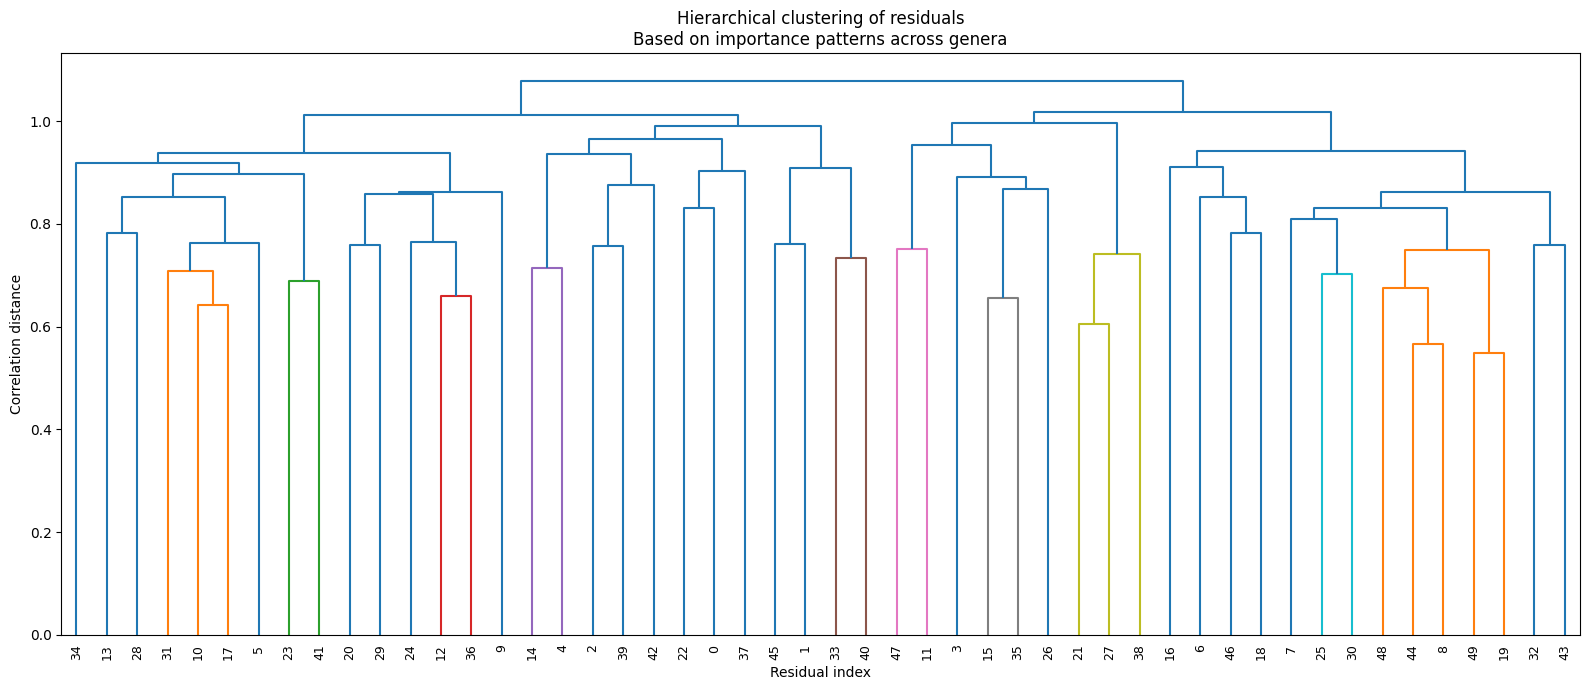

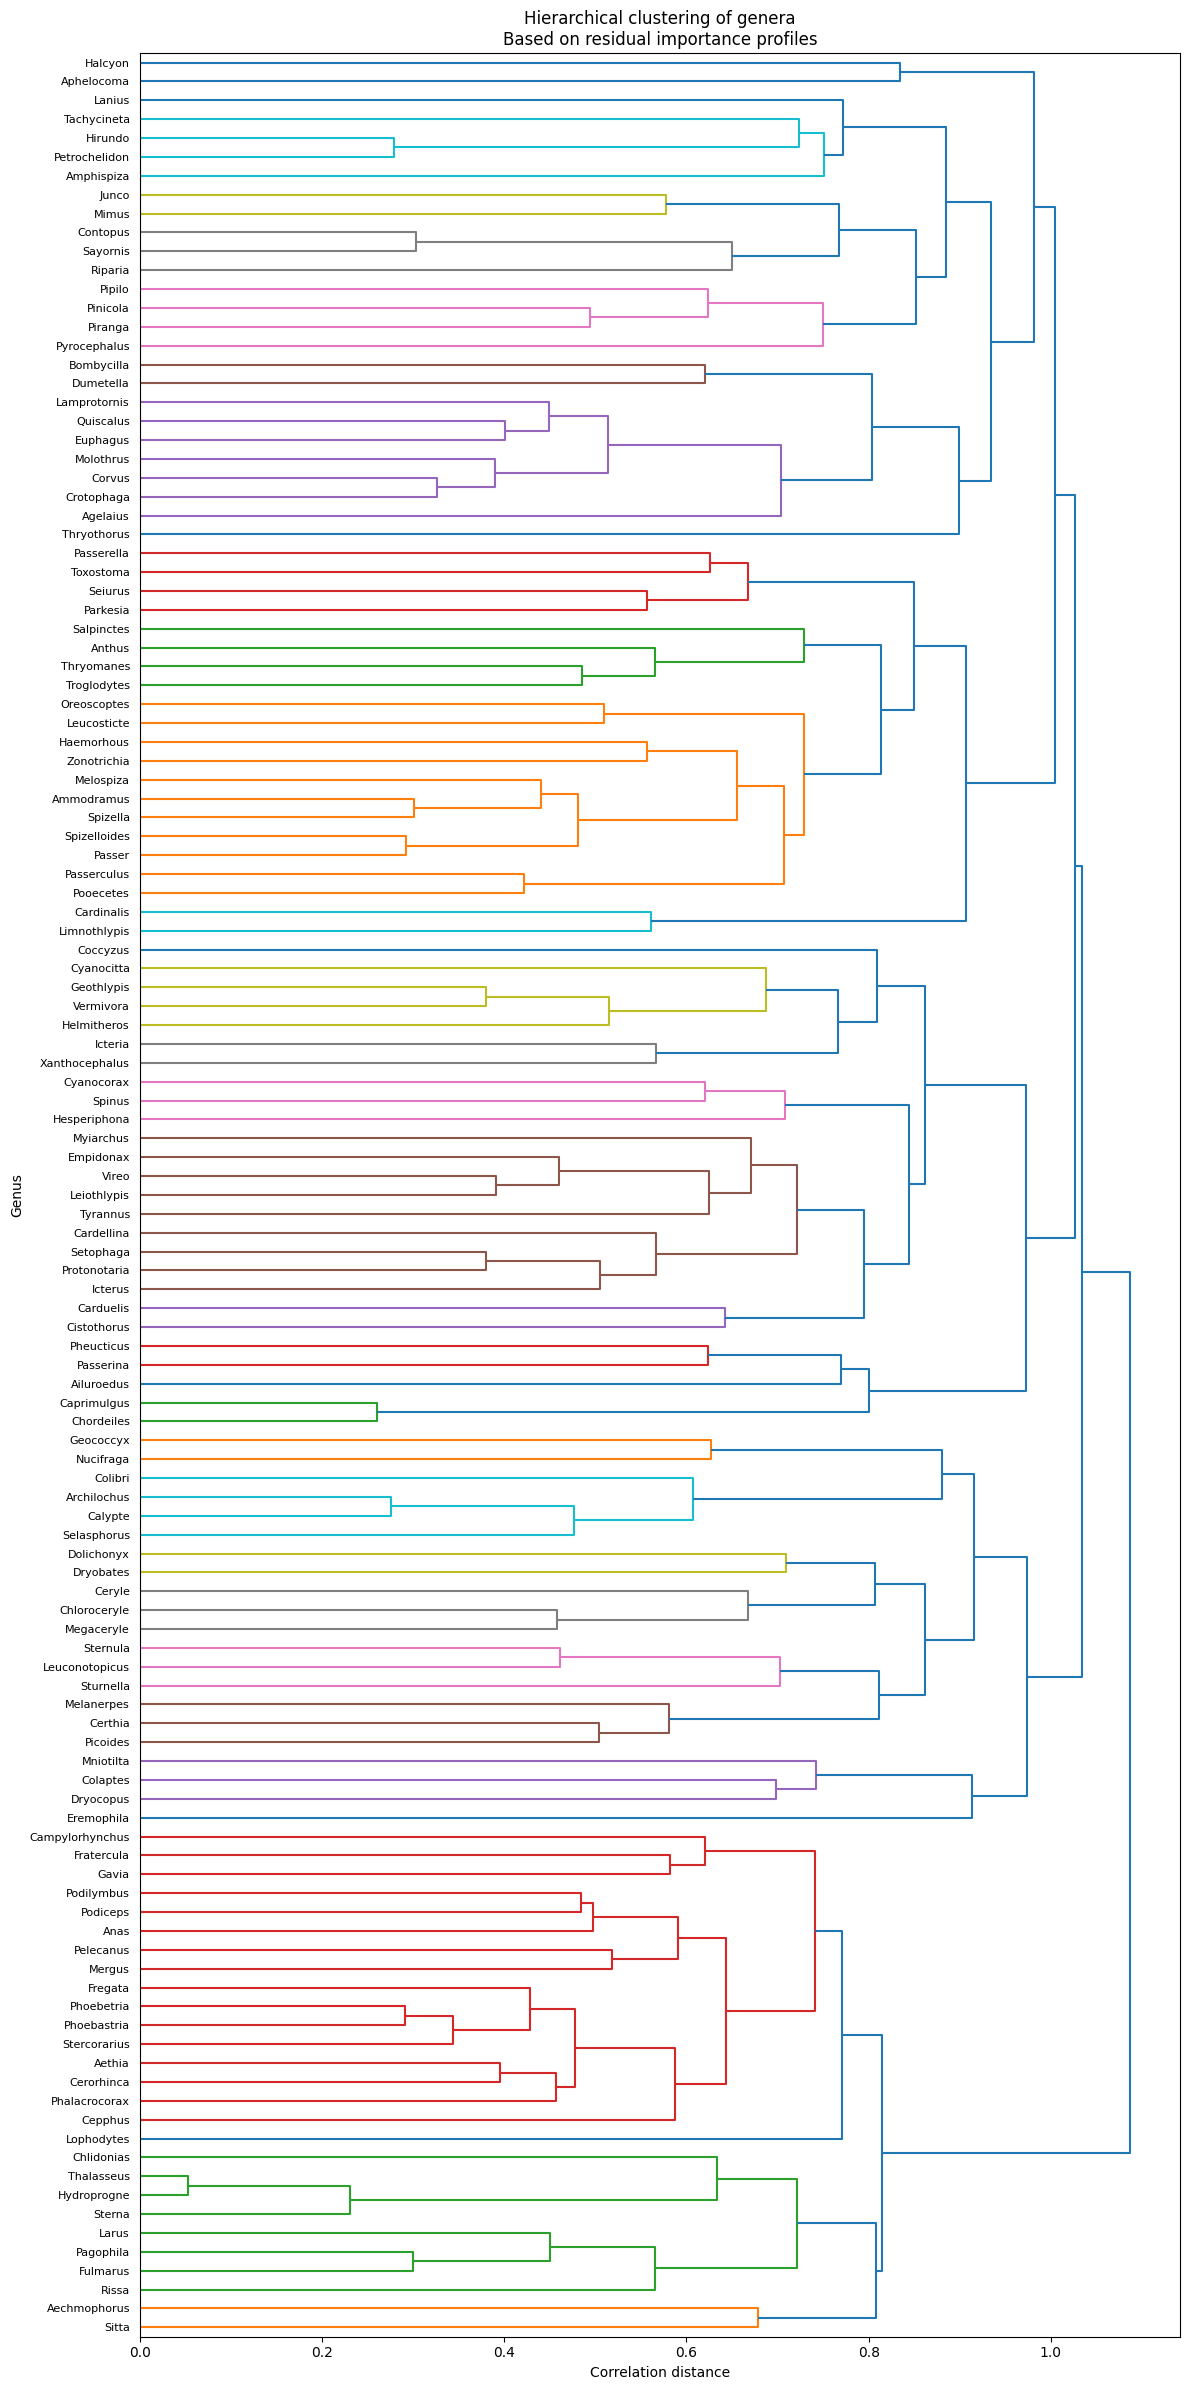

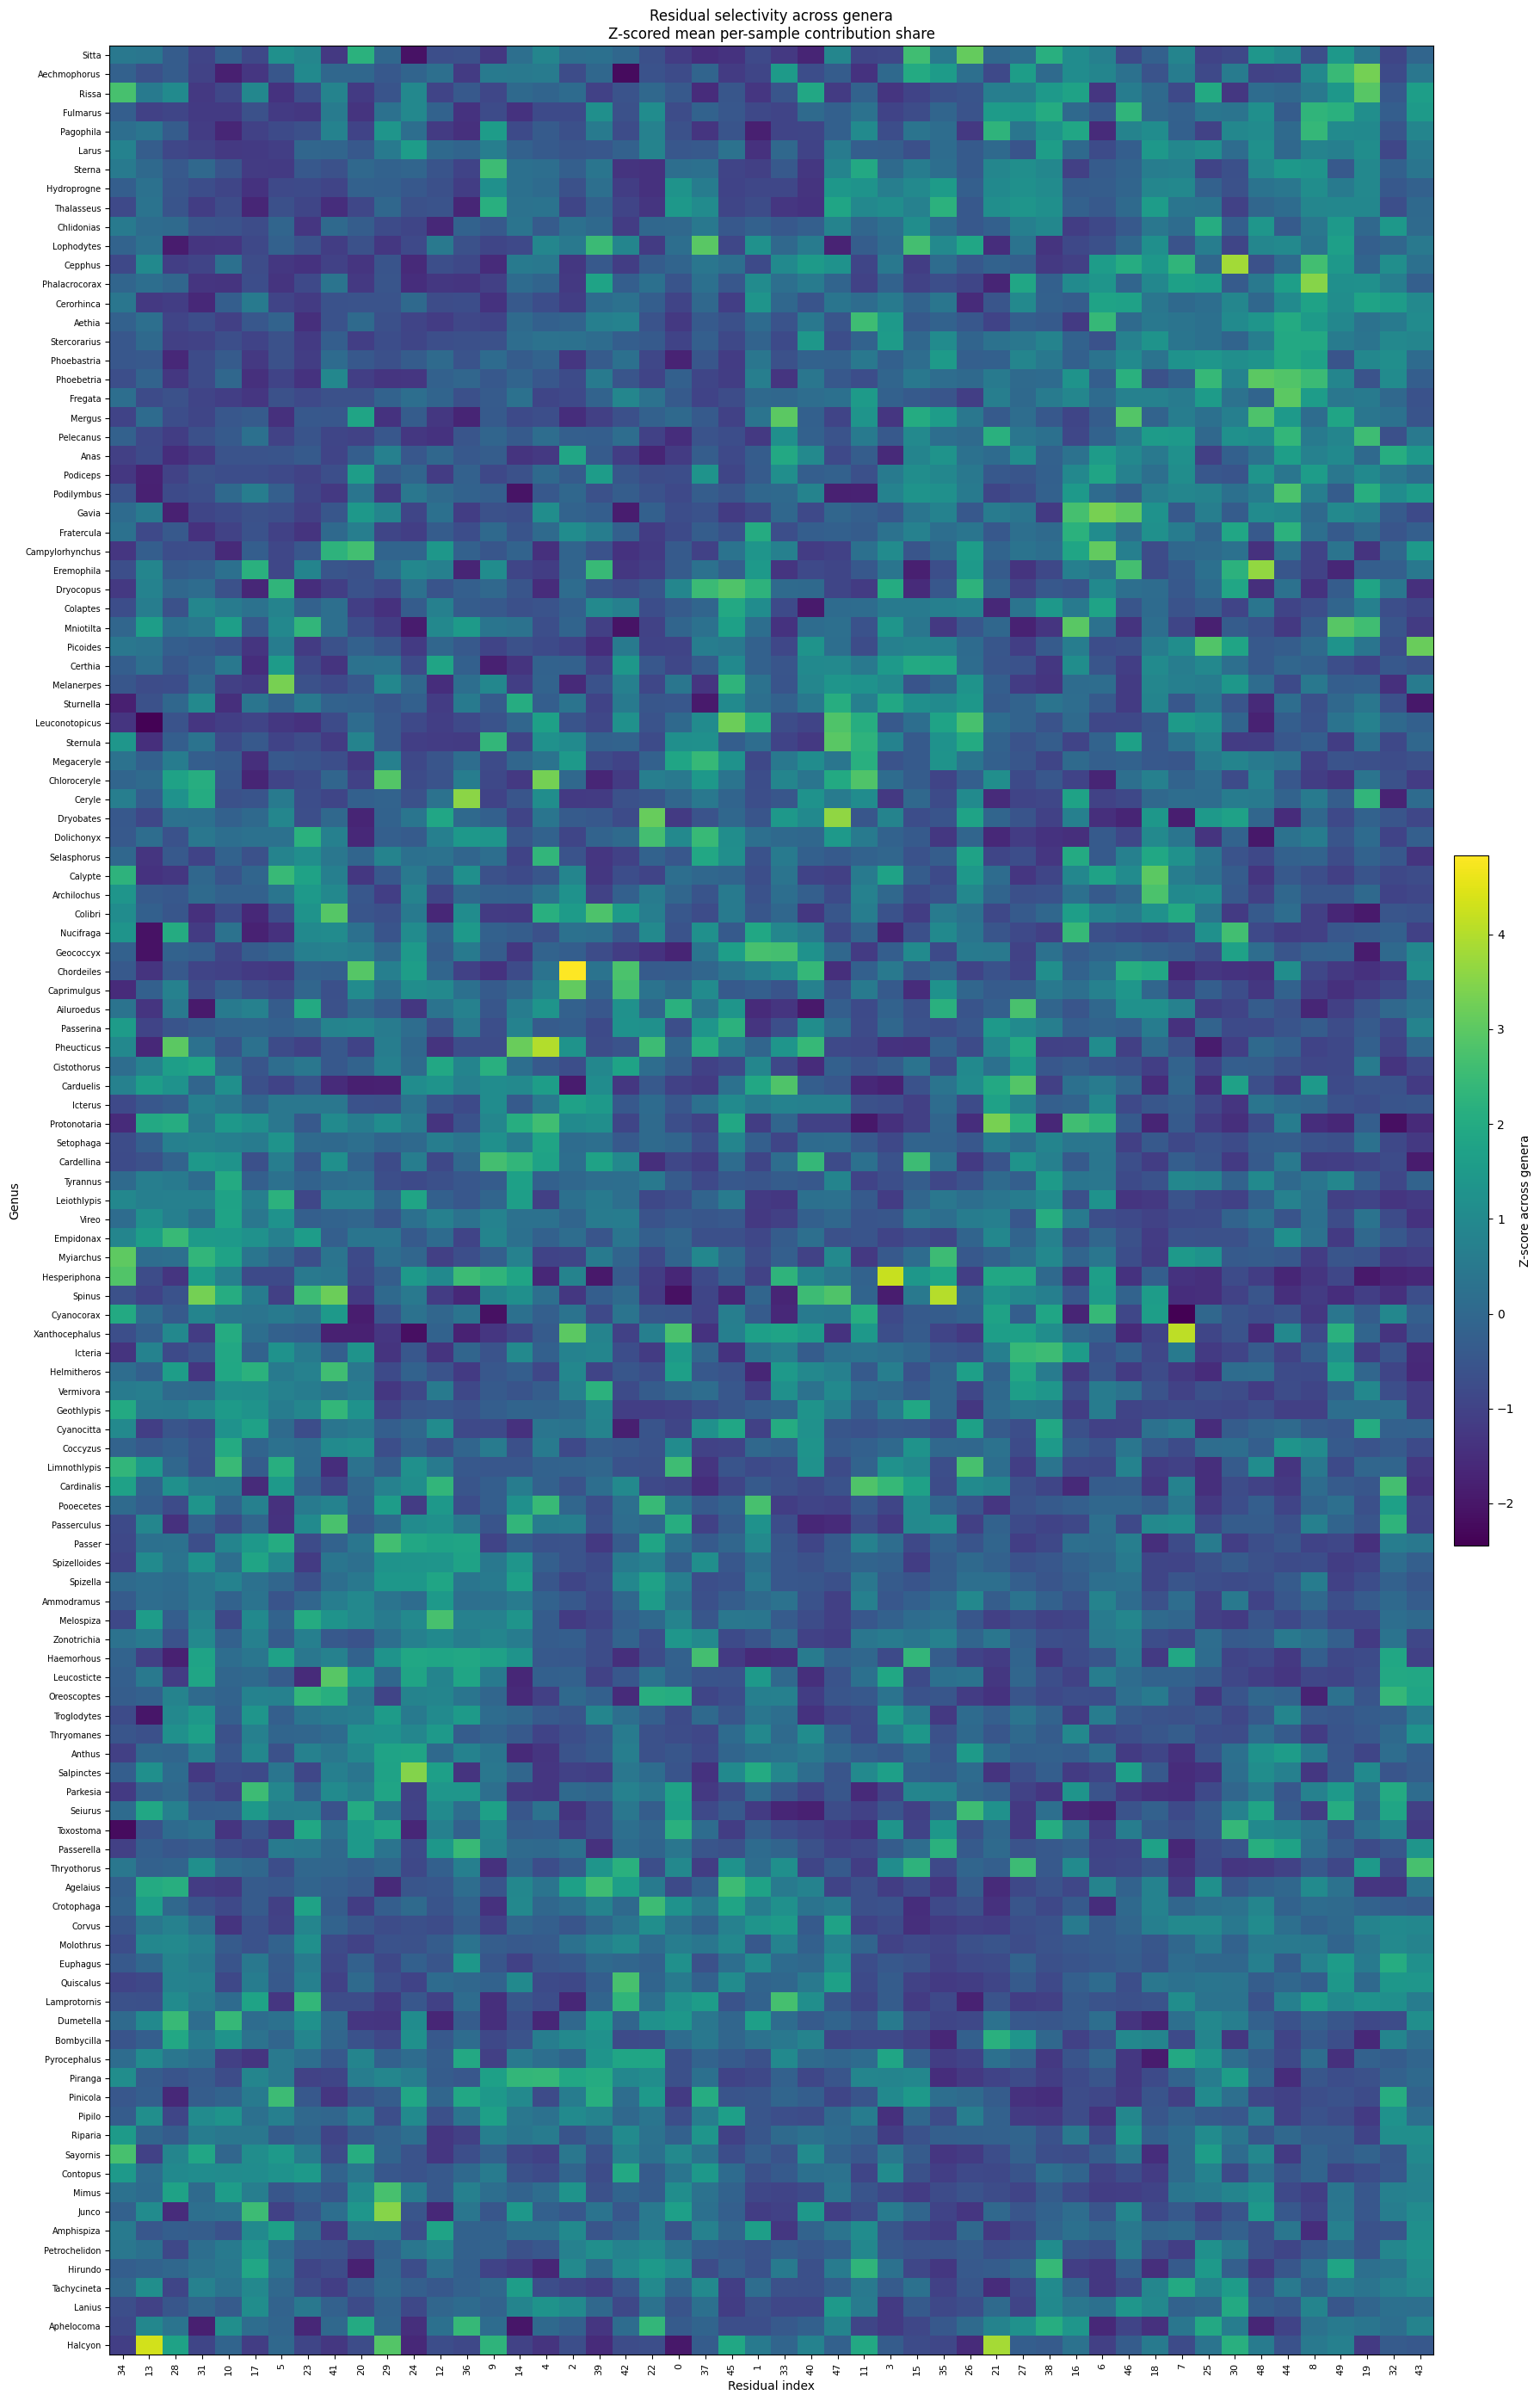

In [ ]:
# ============================================================
# Separate plots:
#   1. Residual dendrogram
#   2. Genus dendrogram
#   3. Clustered genus x residual heatmap
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.cluster.hierarchy import linkage, dendrogram, leaves_list
from scipy.spatial.distance import pdist


# ------------------------------------------------------------
# 1. Create genus x residual matrix
# ------------------------------------------------------------

genus_residual_share = (
    all_residuals_per_genus_df
    .pivot(
        index="genus",
        columns="residual_idx",
        values="mean_per_sample_share",
    )
)

print(
    "Genus x residual matrix:",
    genus_residual_share.shape
)


# ------------------------------------------------------------
# 2. Z-score EACH residual across genera
# ------------------------------------------------------------

genus_residual_z = (
    genus_residual_share
    - genus_residual_share.mean(axis=0)
) / genus_residual_share.std(axis=0, ddof=0)


# ------------------------------------------------------------
# 3. Calculate correlation distances
# ------------------------------------------------------------

# Genera:
# Compare residual-importance patterns between genera
genus_distance = pdist(
    genus_residual_z.values,
    metric="correlation",
)

# Residuals:
# Compare genus-selectivity patterns between residuals
residual_distance = pdist(
    genus_residual_z.values.T,
    metric="correlation",
)


# ------------------------------------------------------------
# 4. Hierarchical clustering
# ------------------------------------------------------------

genus_linkage = linkage(
    genus_distance,
    method="average",
    optimal_ordering=True,
)

residual_linkage = linkage(
    residual_distance,
    method="average",
    optimal_ordering=True,
)


# ------------------------------------------------------------
# 5. Get clustered ordering
# ------------------------------------------------------------

genus_order = leaves_list(genus_linkage)
residual_order = leaves_list(residual_linkage)

clustered_z = genus_residual_z.iloc[
    genus_order,
    residual_order,
]


# ============================================================
# PLOT 1: Residual clustering
# ============================================================

plt.figure(figsize=(16, 7))

dendrogram(
    residual_linkage,
    labels=genus_residual_z.columns.astype(int).astype(str),
    leaf_rotation=90,
    leaf_font_size=9,
)

plt.title(
    "Hierarchical clustering of residuals\n"
    "Based on importance patterns across genera"
)

plt.xlabel("Residual index")
plt.ylabel("Correlation distance")

plt.tight_layout()
plt.show()


# ============================================================
# PLOT 2: Genus clustering
# ============================================================

plt.figure(figsize=(12, 24))

dendrogram(
    genus_linkage,
    labels=genus_residual_z.index.astype(str),
    orientation="right",
    leaf_font_size=8,
)

plt.title(
    "Hierarchical clustering of genera\n"
    "Based on residual importance profiles"
)

plt.xlabel("Correlation distance")
plt.ylabel("Genus")

plt.tight_layout()
plt.show()


# ============================================================
# PLOT 3: Clustered heatmap
# ============================================================

fig, ax = plt.subplots(
    figsize=(18, 28)
)

im = ax.imshow(
    clustered_z.values,
    aspect="auto",
    interpolation="nearest",
)

# Residual labels
ax.set_xticks(
    np.arange(clustered_z.shape[1])
)

ax.set_xticklabels(
    clustered_z.columns.astype(int),
    rotation=90,
    fontsize=8,
)

# Genus labels
ax.set_yticks(
    np.arange(clustered_z.shape[0])
)

ax.set_yticklabels(
    clustered_z.index,
    fontsize=7,
)

ax.set_xlabel("Residual index")
ax.set_ylabel("Genus")

ax.set_title(
    "Residual selectivity across genera\n"
    "Z-scored mean per-sample contribution share"
)

cbar = fig.colorbar(
    im,
    ax=ax,
    fraction=0.025,
    pad=0.015,
)

cbar.set_label(
    "Z-score across genera"
)

plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# Rank all genus x residual pairs by selectivity
# ============================================================

# genus_residual_z:
# rows    = genera
# columns = residual indices
# values  = z-scored mean per-sample contribution share


# ------------------------------------------------------------
# 1. Convert matrix into long-form dataframe
# ------------------------------------------------------------

ranked_pairs = (
    genus_residual_z
    .stack()
    .reset_index()
)

ranked_pairs.columns = [
    "genus",
    "residual_idx",
    "z_score",
]


# ------------------------------------------------------------
# 2. Add original contribution share
# ------------------------------------------------------------

share_long = (
    genus_residual_share
    .stack()
    .reset_index()
)

share_long.columns = [
    "genus",
    "residual_idx",
    "mean_per_sample_share",
]

ranked_pairs = ranked_pairs.merge(
    share_long,
    on=["genus", "residual_idx"],
    how="left",
)


# ------------------------------------------------------------
# 3. Rank pairs
# ------------------------------------------------------------
# Highest z-score =
# residual is unusually important for this genus

ranked_pairs = (
    ranked_pairs
    .sort_values(
        "z_score",
        ascending=False,
    )
    .reset_index(drop=True)
)

ranked_pairs["pair_rank"] = (
    np.arange(1, len(ranked_pairs) + 1)
)


# ------------------------------------------------------------
# 4. Show strongest genus-residual associations
# ------------------------------------------------------------

print(
    ranked_pairs.head(50).to_string(index=False)
)

ranked_pairs.to_csv(
    "delete_afterwards/ranked_genus_residual_pairs_z_scores.csv",
    index=False,
)

          genus  residual_idx  z_score  mean_per_sample_share  pair_rank
     Chordeiles             2 4.832783               0.065626          1
        Halcyon            13 4.336456               0.053360          2
   Hesperiphona             3 4.228029               0.056458          3
 Xanthocephalus             7 4.102516               0.054146          4
         Spinus            35 4.009276               0.064120          5
     Pheucticus             4 3.983581               0.048847          6
        Halcyon            21 3.842562               0.052775          7
        Cepphus            30 3.835228               0.061333          8
     Eremophila            48 3.644096               0.045136          9
      Dryobates            47 3.635631               0.048839         10
         Ceryle            36 3.580333               0.049802         11
  Phalacrocorax             8 3.525456               0.048699         12
          Junco            29 3.509792             

Number of residual - genera pairs with z-score over 2

Top pairs for each residual

In [ ]:
# Residual - genera pairs with z-score over 2
strong_residuals_per_genus = (
    ranked_pairs[
        ranked_pairs["z_score"] >= 2
    ]
    .sort_values(
        ["genus", "z_score"],
        ascending=[True, False],
    )
    .reset_index(drop=True)
)

display(strong_residuals_per_genus.head(20))

print(
    f"Number of residual - genera pairs with z-score >= 2: "
    f"{strong_residuals_per_genus.shape[0]}"
)

strong_residuals_per_genus.to_csv(
    "delete_afterwards/strong_residuals_per_genus_z_scores.csv",
    index=False,
)

,genus,residual_idx,z_score,mean_per_sample_share,pair_rank
0,Aechmophorus,19,3.301984,0.049336,20
1,Aechmophorus,49,2.501148,0.044086,117
2,Aethia,11,2.574101,0.044111,98
3,Aethia,6,2.429084,0.037668,134
4,Aethia,44,2.002306,0.032903,258
5,Agelaius,39,2.575037,0.042139,97
6,Agelaius,45,2.556031,0.046395,102
7,Agelaius,28,2.130139,0.042138,207
8,Agelaius,13,2.017462,0.036033,250
9,Ailuroedus,27,2.757852,0.044968,63


Number of residual - genera pairs with z-score >= 2: 258


In [ ]:
# For each residual find the number of genera with z_score >= 2
residual_genus_counts = (
    strong_residuals_per_genus
    .groupby("residual_idx")
    .size()
)

residual_genus_counts.head(50)
residual_genus_counts.to_csv(
    "delete_afterwards/residual_genus_counts_z_score_ge_2.csv",
    header=["num_genera"],
    index=True,
)

Top residuals for each genus

In [ ]:
top_residuals_per_genus = (
    ranked_pairs
    .sort_values(
        ["genus", "z_score"],
        ascending=[True, False],
    )
    .groupby("genus")
    .head(10)
    .reset_index(drop=True)
)

print(top_residuals_per_genus)

             genus  residual_idx   z_score  mean_per_sample_share  pair_rank
0     Aechmophorus            19  3.301984               0.049336         20
1     Aechmophorus            49  2.501148               0.044086        117
2     Aechmophorus            15  1.991268               0.038383        260
3     Aechmophorus            27  1.617811               0.034631        455
4     Aechmophorus            35  1.564417               0.037730        486
...            ...           ...       ...                    ...        ...
1205   Zonotrichia            35  0.757494               0.029021       1284
1206   Zonotrichia            24  0.718803               0.027282       1351
1207   Zonotrichia            17  0.713239               0.025037       1357
1208   Zonotrichia            23  0.697074               0.027502       1377
1209   Zonotrichia            36  0.634457               0.024568       1450

[1210 rows x 5 columns]


In [ ]:
# ============================================================
# Find genera that share multiple strongly selective residuals
# ============================================================

import numpy as np
import pandas as pd


# ------------------------------------------------------------
# 1. Binary genus x residual matrix
# ------------------------------------------------------------
# 1 = residual has z >= 2 for this genus
# 0 = otherwise

binary_matrix = (
    ranked_pairs
    .assign(strong=lambda x: (x["z_score"] >= 2).astype(int))
    .pivot(
        index="genus",
        columns="residual_idx",
        values="strong",
    )
    .fillna(0)
    .astype(int)
)



# ------------------------------------------------------------
# 2. Number of shared strong residuals
# ------------------------------------------------------------

shared_counts = binary_matrix @ binary_matrix.T





# ------------------------------------------------------------
# 3. Convert to ranked dataframe
# ------------------------------------------------------------

rows = []

genera = binary_matrix.index

for i in range(len(genera)):
    for k in range(i + 1, len(genera)):

        genus_1 = genera[i]
        genus_2 = genera[k]

        count = shared_counts.iloc[i, k]

        if count < 2:
            continue

        # Which residuals do they actually share?
        shared_mask = (
            (binary_matrix.loc[genus_1] == 1)
            &
            (binary_matrix.loc[genus_2] == 1)
        )

        shared_residuals = (
            binary_matrix.columns[shared_mask]
            .astype(int)
            .tolist()
        )

        rows.append(
            {
                "genus_1": genus_1,
                "genus_2": genus_2,
                "num_shared_residuals": int(count),
                "shared_residuals": shared_residuals,
            }
        )


shared_residual_pairs = (
    pd.DataFrame(rows)
    .sort_values(
        "num_shared_residuals",
        ascending=False,
    )
    .reset_index(drop=True)
)

shared_residual_pairs

,genus_1,genus_2,num_shared_residuals,shared_residuals
0,Oreoscoptes,Passerculus,3,"[0, 32, 41]"
1,Leuconotopicus,Sternula,3,"[11, 26, 47]"
2,Pheucticus,Protonotaria,3,"[4, 14, 28]"
3,Dryocopus,Leuconotopicus,3,"[1, 26, 45]"
4,Nucifraga,Protonotaria,2,"[16, 28]"
5,Limnothlypis,Xanthocephalus,2,"[0, 10]"
6,Lophodytes,Pinicola,2,"[37, 39]"
7,Mergus,Phoebetria,2,"[46, 48]"
8,Myiarchus,Spinus,2,"[31, 35]"
9,Aechmophorus,Mniotilta,2,"[19, 49]"


## Family analysis

In [ ]:
cub_taxonomy_df.head(10)

family_to_class_idx_dict = {}

for _, row in cub_taxonomy_df.iterrows():
    family = row["family"]
    class_idx = row["class_idx"]

    if pd.isna(family):
        continue

    if family not in family_to_class_idx_dict:
        family_to_class_idx_dict[family] = []

    family_to_class_idx_dict[family].append(class_idx)
    
print("Family to class_idx mapping:")
for family, class_indices in family_to_class_idx_dict.items():
    print(f"  {family}: {class_indices}")

Family to class_idx mapping:
  Diomedeidae: [0, 1, 2]
  Cuculidae: [3, 30, 31, 32, 109]
  Alcidae: [4, 5, 6, 7, 57, 105]
  Icteridae: [8, 9, 10, 11, 12, 25, 26, 48, 87, 94, 95, 96, 97]
  Cardinalidae: [13, 14, 15, 16, 53, 56, 138, 139]
  Ptilonorhynchidae: [17]
  Mimidae: [18, 90, 148, 149]
  Icteriidae: [19]
  Passerellidae: [20, 75, 112, 113, 114, 115, 116, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130, 131, 132, 147]
  Caprimulgidae: [21, 91, 104]
  Phalacrocoracidae: [22, 23, 24]
  Certhiidae: [27]
  Corvidae: [28, 29, 72, 73, 74, 92, 106, 107]
  Fringillidae: [33, 34, 46, 47, 54, 55]
  Picidae: [35, 186, 187, 188, 189, 190, 191]
  Tyrannidae: [36, 37, 38, 39, 40, 41, 42, 76, 77, 101, 102]
  Fregatidae: [43]
  Procellariidae: [44]
  Anatidae: [45, 86, 88, 89]
  Podicipedidae: [49, 50, 51, 52]
  Laridae: [58, 59, 60, 61, 62, 63, 64, 65, 83, 140, 141, 142, 143, 144, 145, 146]
  Trochilidae: [66, 67, 68, 69]
  Stercorariidae: [70, 71]
  Alcedinidae: [78, 79, 80, 81, 

### Get importance of residual for family level

In [ ]:
# ============================================================
# Get mean and std rank of residual importance per family
# ============================================================

import numpy as np
import torch


# Reuses per_sample_residual_ranks and abs_phi_r computed in the
# genus block above (same phi_r, same per-sample ranking), so
# they are not recomputed here.

num_samples, num_residuals = phi_r.shape

assert num_residuals == R, (
    f"phi_r has {num_residuals} residual dimensions, "
    f"but R={R}."
)

assert per_sample_residual_ranks.shape == (num_samples, R)


# ------------------------------------------------------------
# Aggregate ranks within each family
# ------------------------------------------------------------

family_names = sorted(family_to_class_idx_dict.keys())

num_families = len(family_names)

family_to_idx = {
    family: family_idx
    for family_idx, family in enumerate(family_names)
}


per_family_mean_rank = torch.full(
    (num_families, R),
    float("nan"),
    dtype=phi_r.dtype,
    device=phi_r.device,
)

per_family_std_rank = torch.full(
    (num_families, R),
    float("nan"),
    dtype=phi_r.dtype,
    device=phi_r.device,
)

per_family_median_rank = torch.full(
    (num_families, R),
    float("nan"),
    dtype=phi_r.dtype,
    device=phi_r.device,
)

per_family_mean_abs_contribution = torch.full(
    (num_families, R),
    float("nan"),
    dtype=phi_r.dtype,
    device=phi_r.device,
)

per_family_mean_contribution_share = torch.full(
    (num_families, R),
    float("nan"),
    dtype=residual_contribution_share.dtype,
    device=residual_contribution_share.device,
)

per_family_std_contribution_share = torch.full(
    (num_families, R),
    float("nan"),
    dtype=residual_contribution_share.dtype,
    device=residual_contribution_share.device,
)

num_samples_per_family = torch.zeros(
    num_families,
    dtype=torch.long,
    device=phi_r.device,
)

num_classes_per_family = torch.zeros(
    num_families,
    dtype=torch.long,
    device=phi_r.device,
)


for family_idx, family in enumerate(family_names):

    class_indices = family_to_class_idx_dict[family]

    class_indices_tensor = torch.tensor(
        class_indices,
        dtype=y_true.dtype,
        device=y_true.device,
    )

    # True if the sample belongs to ANY class in this family
    family_mask = torch.isin(
        y_true,
        class_indices_tensor,
    )

    family_count = int(family_mask.sum().item())

    num_samples_per_family[family_idx] = family_count
    num_classes_per_family[family_idx] = len(class_indices)

    if family_count == 0:
        continue

    family_ranks = per_sample_residual_ranks[family_mask]

    per_family_mean_rank[family_idx] = (
        family_ranks.mean(dim=0)
    )

    per_family_std_rank[family_idx] = (
        family_ranks.std(
            dim=0,
            correction=0,
        )
    )

    per_family_median_rank[family_idx] = (
        family_ranks.median(dim=0).values
    )

    family_abs_contribution = abs_phi_r[family_mask]

    per_family_mean_abs_contribution[family_idx] = (
        family_abs_contribution.mean(dim=0)
    )

    family_share = residual_contribution_share[family_mask]

    per_family_mean_contribution_share[family_idx] = (
        family_share.mean(dim=0)
    )

    per_family_std_contribution_share[family_idx] = (
        family_share.std(
            dim=0,
            correction=0,
        )
    )


print(
    "per_family_mean_rank.shape:",
    tuple(per_family_mean_rank.shape),
)

print(
    "per_family_mean_contribution_share.shape:",
    tuple(per_family_mean_contribution_share.shape),
)


# ------------------------------------------------------------
# Inspect the family with the most samples, as a sanity check
# ------------------------------------------------------------

family_to_inspect = family_names[
    int(torch.argmax(num_samples_per_family).item())
]

num_to_show = min(10, R)

family_idx = family_to_idx[family_to_inspect]

family_count = int(
    num_samples_per_family[family_idx].item()
)

class_indices = family_to_class_idx_dict[family_to_inspect]

residual_order = torch.argsort(
    per_family_mean_rank[family_idx],
    descending=False,
)

print(
    f"\nResidual importance ranks for family "
    f"{family_to_inspect}"
)

print(f"Classes: {class_indices}")
print(f"Number of classes: {len(class_indices)}")
print(f"Number of samples: {family_count}")

for position, residual_idx in enumerate(
    residual_order[:num_to_show],
    start=1,
):
    j = int(residual_idx.item())

    mean_rank = per_family_mean_rank[family_idx, j].item()
    mean_contribution_share = (
        per_family_mean_contribution_share[family_idx, j].item()
    )

    print(
        f"{position:2d}. residual {j:2d} | "
        f"mean rank = {mean_rank:.2f} | "
        f"mean share = {mean_contribution_share:.4f}"
    )


In [ ]:
# ============================================================
# DataFrame with all ranked residuals for every family
# ============================================================

import pandas as pd
import torch

num_to_show = NUM_RESIDUALS

rows = []

for family_idx, family in enumerate(family_names):

    family_count = int(
        num_samples_per_family[family_idx].item()
    )

    class_indices = family_to_class_idx_dict[family]

    class_names = [
        class_names_names[class_idx]
        for class_idx in class_indices
    ]

    num_classes = len(class_indices)

    # ----------------------------------------------------
    # Keep family in output even if it has no samples
    # ----------------------------------------------------

    if family_count == 0:

        for position in range(1, num_to_show + 1):

            rows.append(
                {
                    "family": family,
                    "num_classes": num_classes,
                    "class_indices": class_indices,
                    "class_names": class_names,
                    "num_samples": 0,

                    "residual_position": position,
                    "residual_idx": pd.NA,

                    "mean_rank": float("nan"),
                    "std_rank": float("nan"),
                    "median_rank": float("nan"),
                    "mean_abs_contribution": float("nan"),
                    "mean_per_sample_share": float("nan"),
                    "std_per_sample_share": float("nan"),
                }
            )

        continue

    # ----------------------------------------------------
    # Rank residuals for this family
    #
    # Lower mean rank = more consistently important
    # ----------------------------------------------------

    residual_order = torch.argsort(
        per_family_mean_rank[family_idx],
        descending=False,
    )

    top_residual_indices = residual_order[:num_to_show]

    for position, residual_idx in enumerate(
        top_residual_indices,
        start=1,
    ):

        j = int(residual_idx.item())

        rows.append(
            {
                "family": family,
                "num_classes": num_classes,
                "class_indices": class_indices,
                "class_names": class_names,
                "num_samples": family_count,

                "residual_position": position,
                "residual_idx": j,

                "mean_rank": (
                    per_family_mean_rank[family_idx, j].item()
                ),

                "std_rank": (
                    per_family_std_rank[family_idx, j].item()
                ),

                "median_rank": (
                    per_family_median_rank[family_idx, j].item()
                ),

                "mean_abs_contribution": (
                    per_family_mean_abs_contribution[
                        family_idx, j
                    ].item()
                ),

                "mean_per_sample_share": (
                    per_family_mean_contribution_share[
                        family_idx, j
                    ].item()
                ),

                "std_per_sample_share": (
                    per_family_std_contribution_share[
                        family_idx, j
                    ].item()
                ),
            }
        )


all_residuals_per_family_df = pd.DataFrame(rows)

all_residuals_per_family_df["num_classes"] = (
    all_residuals_per_family_df["num_classes"].astype("Int64")
)

all_residuals_per_family_df["num_samples"] = (
    all_residuals_per_family_df["num_samples"].astype("Int64")
)

all_residuals_per_family_df["residual_position"] = (
    all_residuals_per_family_df["residual_position"].astype("Int64")
)

all_residuals_per_family_df["residual_idx"] = (
    all_residuals_per_family_df["residual_idx"].astype("Int64")
)

print(
    "DataFrame shape:",
    all_residuals_per_family_df.shape,
)

all_residuals_per_family_df.to_csv(
    "delete_afterwards/all_residuals_per_family.csv",
    index=False,
)

display(all_residuals_per_family_df.head(70))


## Z-score each residual across families + cluster both axes

In [ ]:
# ============================================================
# Separate plots:
#   1. Residual dendrogram
#   2. Family dendrogram
#   3. Clustered family x residual heatmap
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.cluster.hierarchy import linkage, dendrogram, leaves_list
from scipy.spatial.distance import pdist


# ------------------------------------------------------------
# 1. Create family x residual matrix
# ------------------------------------------------------------

# Families with no test samples were kept as NaN placeholder
# rows in all_residuals_per_family_df, so drop them before
# pivoting (same reasoning as the class-level block above).
family_df_for_pivot = (
    all_residuals_per_family_df
    .dropna(subset=["residual_idx"])
)

family_df_for_pivot = family_df_for_pivot[
    family_df_for_pivot["num_samples"] > 0
]

family_residual_share = (
    family_df_for_pivot
    .pivot(
        index="family",
        columns="residual_idx",
        values="mean_per_sample_share",
    )
)

print(
    "Family x residual matrix:",
    family_residual_share.shape
)


# ------------------------------------------------------------
# 2. Z-score EACH residual across families
# ------------------------------------------------------------

family_share_std = family_residual_share.std(axis=0, ddof=0)

degenerate_residuals = (
    family_share_std.index[family_share_std == 0]
    .astype(int)
    .tolist()
)

if degenerate_residuals:
    print(
        "Residuals with zero variance across families "
        "(z set to 0):",
        degenerate_residuals,
    )

family_residual_z = (
    (
        family_residual_share
        - family_residual_share.mean(axis=0)
    )
    / family_share_std.replace(0.0, np.nan)
).fillna(0.0)


# ------------------------------------------------------------
# 3. Calculate correlation distances
# ------------------------------------------------------------

# Families:
# Compare residual-importance patterns between families
family_distance = pdist(
    family_residual_z.values,
    metric="correlation",
)

# Residuals:
# Compare family-selectivity patterns between residuals
residual_distance = pdist(
    family_residual_z.values.T,
    metric="correlation",
)


# ------------------------------------------------------------
# 4. Hierarchical clustering
# ------------------------------------------------------------

family_linkage = linkage(
    family_distance,
    method="average",
    optimal_ordering=True,
)

residual_linkage = linkage(
    residual_distance,
    method="average",
    optimal_ordering=True,
)


# ------------------------------------------------------------
# 5. Get clustered ordering
# ------------------------------------------------------------

family_order = leaves_list(family_linkage)
residual_order = leaves_list(residual_linkage)

clustered_z = family_residual_z.iloc[
    family_order,
    residual_order,
]


# ============================================================
# PLOT 1: Residual clustering
# ============================================================

plt.figure(figsize=(16, 7))

dendrogram(
    residual_linkage,
    labels=family_residual_z.columns.astype(int).astype(str),
    leaf_rotation=90,
    leaf_font_size=9,
)

plt.title(
    "Hierarchical clustering of residuals\n"
    "Based on importance patterns across families"
)

plt.xlabel("Residual index")
plt.ylabel("Correlation distance")

plt.tight_layout()
plt.show()


# ============================================================
# PLOT 2: Family clustering
# ============================================================

plt.figure(
    figsize=(12, max(6, 0.3 * len(family_residual_z.index)))
)

dendrogram(
    family_linkage,
    labels=family_residual_z.index.astype(str),
    orientation="right",
    leaf_font_size=8,
)

plt.title(
    "Hierarchical clustering of families\n"
    "Based on residual importance profiles"
)

plt.xlabel("Correlation distance")
plt.ylabel("Family")

plt.tight_layout()
plt.show()


# ============================================================
# PLOT 3: Clustered heatmap
# ============================================================

fig, ax = plt.subplots(
    figsize=(18, max(8, 0.35 * len(clustered_z.index)))
)

im = ax.imshow(
    clustered_z.values,
    aspect="auto",
    interpolation="nearest",
)

# Residual labels
ax.set_xticks(np.arange(clustered_z.shape[1]))

ax.set_xticklabels(
    clustered_z.columns.astype(int),
    rotation=90,
    fontsize=8,
)

# Family labels
ax.set_yticks(np.arange(clustered_z.shape[0]))

ax.set_yticklabels(clustered_z.index, fontsize=7)

ax.set_xlabel("Residual index")
ax.set_ylabel("Family")

ax.set_title(
    "Residual selectivity across families\n"
    "Z-scored mean per-sample contribution share"
)

cbar = fig.colorbar(im, ax=ax, fraction=0.025, pad=0.015)

cbar.set_label("Z-score across families")

plt.tight_layout()
plt.show()


In [ ]:
import pickle
with open("/Users/stephenmarcou/Documents/ETH Zurich/Cambridge/Code/SCBM_implementation/datasets/CUB/class_attr_data_10/train.pkl", "rb") as f:
    train_data = pickle.load(f)
    
print(train_data[0].keys())

for i in range(10):
    print(f"Sample {i}:")
    print(f"  Image path: {train_data[i]['img_path']}")
    print(f"  Class index: {train_data[i]['class_label']}")
    print(f"  ID: {train_data[i]['id']}")


dict_keys(['id', 'img_path', 'class_label', 'attribute_label', 'attribute_certainty'])
Sample 0:
  Image path: /juice/scr/scr102/scr/thaonguyen/CUB_supervision/datasets/CUB_200_2011/images/022.Chuck_will_Widow/Chuck_Will_Widow_0059_796982.jpg
  Class index: 21
  ID: 1210
Sample 1:
  Image path: /juice/scr/scr102/scr/thaonguyen/CUB_supervision/datasets/CUB_200_2011/images/052.Pied_billed_Grebe/Pied_Billed_Grebe_0070_35472.jpg
  Class index: 51
  ID: 2987
Sample 2:
  Image path: /juice/scr/scr102/scr/thaonguyen/CUB_supervision/datasets/CUB_200_2011/images/063.Ivory_Gull/Ivory_Gull_0089_49699.jpg
  Class index: 62
  ID: 3621
Sample 3:
  Image path: /juice/scr/scr102/scr/thaonguyen/CUB_supervision/datasets/CUB_200_2011/images/169.Magnolia_Warbler/Magnolia_Warbler_0015_165817.jpg
  Class index: 168
  ID: 9938
Sample 4:
  Image path: /juice/scr/scr102/scr/thaonguyen/CUB_supervision/datasets/CUB_200_2011/images/001.Black_footed_Albatross/Black_Footed_Albatross_0077_796114.jpg
  Class index: 0

/var/folders/wb/9whmmh7s5bvf174ppr2jwprr0000gn/T/ipykernel_44355/280016815.py:3: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  train_data = pickle.load(f)


In [ ]:
with open("/Users/stephenmarcou/Documents/ETH Zurich/Cambridge/Code/SCBM_implementation/datasets/CUB/class_attr_data_10/train.pkl", "rb") as f:
    dataset = pickle.load(f)

for i in range(10):

    parts = dataset[i]["img_path"].split("/")
    index = parts.index("images")
    end_path = "/".join(parts[index + 1:])


    new_path = os.path.join(
        "datasets", "TravelingBirds/train/", end_path
    )
    
    assert os.path.exists(new_path), f"Path does not exist: {new_path}"

    print(new_path)






/var/folders/wb/9whmmh7s5bvf174ppr2jwprr0000gn/T/ipykernel_44355/3986842605.py:2: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  dataset = pickle.load(f)


datasets/TravelingBirds/train/022.Chuck_will_Widow/Chuck_Will_Widow_0059_796982.jpg
datasets/TravelingBirds/train/052.Pied_billed_Grebe/Pied_Billed_Grebe_0070_35472.jpg
datasets/TravelingBirds/train/063.Ivory_Gull/Ivory_Gull_0089_49699.jpg
datasets/TravelingBirds/train/169.Magnolia_Warbler/Magnolia_Warbler_0015_165817.jpg
datasets/TravelingBirds/train/001.Black_footed_Albatross/Black_Footed_Albatross_0077_796114.jpg
datasets/TravelingBirds/train/071.Long_tailed_Jaeger/Long_Tailed_Jaeger_0009_797070.jpg
datasets/TravelingBirds/train/025.Pelagic_Cormorant/Pelagic_Cormorant_0038_23643.jpg
datasets/TravelingBirds/train/101.White_Pelican/White_Pelican_0042_97250.jpg
datasets/TravelingBirds/train/097.Orchard_Oriole/Orchard_Oriole_0084_91658.jpg
datasets/TravelingBirds/train/127.Savannah_Sparrow/Savannah_Sparrow_0091_120630.jpg
